# 002. Transformer Block

**残差接続・層正規化・順伝播ネットワークによるブロック構築 — Encoder Block と Decoder Block**
*From Residual Connections and Normalization to Encoder / Decoder Blocks*

`theories/01_foundations/002_transformer_block.ipynb`

## 1. 概要 / Overview

[001](./001_attention_mechanism.ipynb) で実装した **多頭注意機構(Multi-Head Attention)** は、系列中の任意の 2 位置を $O(1)$ の経路で結びつけられる一方、(1) 各位置内での非線形な特徴変換を持たず、(2) 層を深く積むと勾配が不安定になりやすいという 2 つの限界を持つ。本ノートブックでは、**残差接続(Residual Connection)** ・ **層正規化(Layer Normalization)** ・ **順伝播ネットワーク(Feed-Forward Network)** を多頭注意機構と組み合わせることで、これらを補う **Transformer Block** を構成する。

具体的には、(1) 残差接続・層正規化・順伝播ネットワークをそれぞれスクラッチ実装し、(2) 正規化を残差経路の前に置く **正規化前置(Pre-Layer Normalization)** と後に置く **正規化後置(Post-Layer Normalization)** という 2 つの構造を比較し、(3) 自己注意のみからなる **Encoder Block** と、交差注意(cross-attention)を含む **Decoder Block** を実装する。あわせて、系列の順序情報を与えるために **正弦波(sinusoidal)方式の位置エンコーディング(Positional Encoding)を暫定的に** 導入する(この方式を選ぶ理論的根拠には踏み込まず、あくまで実験を成立させるための足場として扱う。詳細は 3.6 節の注記を参照)。

正規化・活性化関数のさらなる発展(RMSNorm、SwiGLU など)は [004](./004_normalization_activation.ipynb) (未作成)で、位置エンコーディングの各方式の比較・回転位置エンコーディング(RoPE)は [003](./003_positional_encoding_rope.ipynb) (未作成)で、学習を安定化させる warmup などの最適化技術は 007(未作成)で扱う。

## 2. 参考論文 / References

| # | 著者 / Authors | タイトル / Title | 会議・媒体 / Venue | URL |
|---|---|---|---|---|
| [1] | Vaswani, Shazeer, Parmar, Uszkoreit, Jones, Gomez, Kaiser, Polosukhin | Attention Is All You Need | NeurIPS 2017 | https://arxiv.org/abs/1706.03762 |
| [2] | Ba, Kiros, Hinton | Layer Normalization | arXiv 2016 | https://arxiv.org/abs/1607.06450 |
| [3] | Xiong, Yang, He, Zheng, Zheng, Xing, Zhang, Lan, Wang, Liu | On Layer Normalization in the Transformer Architecture | ICML 2020 | https://arxiv.org/abs/2002.04745 |
| [4] | He, Zhang, Ren, Sun | Deep Residual Learning for Image Recognition | CVPR 2016 | https://arxiv.org/abs/1512.03385 |
| [5] | Elhage, Nanda, Olsson, et al. | A Mathematical Framework for Transformer Circuits | Transformer Circuits Thread, 2021 | https://transformer-circuits.pub/2021/framework/index.html |
| [6] | Olsson, Elhage, Nanda, et al. | In-context Learning and Induction Heads | Transformer Circuits Thread, 2022 | https://arxiv.org/abs/2209.11895 |
| [7] | Veit, Wilber, Belongie | Residual Networks Behave Like Ensembles of Relatively Shallow Networks | NeurIPS 2016 | https://arxiv.org/abs/1605.06431 |

- **[1] が本トピックの原典。** Encoder / Decoder のブロック構造(3.7 節)、順伝播ネットワーク(3.4 節)、正弦波位置エンコーディング(3.6 節)はすべてこの論文に基づく。原論文の構成は正規化後置(Post-Layer Normalization)である。
- **[2] は層正規化の原典。** 平均・分散の計算軸の定義に用いる。
- **[3] は正規化前置・正規化後置の勾配挙動を理論的に解析した研究** で、実験 2(勾配伝播の比較)の設計と考察の根拠として参照する。
- **[4] は残差接続の原典**(画像領域だが、恒等写像の項を勾配に持つという議論は Transformer にもそのまま当てはまる)。3.2 節の勾配の導出で参照する。
- [5], [6] は 001 の実験 3 でも参照した Attention の解釈可能性研究で、実験 1(ブロック積層による精度改善)で使う induction task(2 ホップの参照を要するタスク)の設計根拠として参照する。
- [7] は、残差接続を持つネットワークが、深さの異なる多数の経路の集合(アンサンブル)のように振る舞うことを示した研究で、3.2 節の「入力側の勾配が恒等写像だけを通る経路を含む $2^L$ 通りの経路の和になる」という解釈の根拠として参照する。

## 3. 理論 / Theory

**表記の約束**: 本ノートブックでは、系列を行方向に並べた行ベクトル規約($x$ を行ベクトルとして右から重みを掛ける)を用いる。これは原論文 [1] および 001 の表記、PyTorch の `nn.Linear` の実装と一致する。

### 3.1 動機・課題 / Motivation

001 で見た通り、多頭注意機構は「$O(1)$ の経路で任意の位置を選択的に参照できる」という強力な性質を持つ。しかし、多頭注意機構 **だけ** を積み重ねても、実用的な Transformer にはならない。理由は大きく 2 つある。

**(a) 位置ごとの非線形変換の欠如。** Attention の出力 $z_i = \sum_j a_{ij} v_j$ は、Value $v_j = x_j W^V$ の **凸結合(重み $a_{ij} \ge 0$、$\sum_j a_{ij}=1$)** である。$W^V$ は線形変換であり、softmax の重み自体は非線形だが、Value 側の変換そのものには非線形性がない。複数ヘッドを結合したあとの $W^O$ も線形である。つまり、多頭注意機構だけを積み重ねても、各位置の表現に対して行われる変換は「他位置の情報を線形結合する」ことに留まり、**各位置内で表現を非線形に変換する** 機構が存在しない。

**(b) 深層化に伴う勾配の不安定性。** $L$ 層を単純に $x_L = f_L(f_{L-1}(\cdots f_1(x_0) \cdots))$ と合成すると、逆伝播の勾配は $L$ 個のヤコビアンの積になる。001 の実験 1 で見たように、Attention のヤコビアンは softmax が飽和するほど 0 に近づきうる(ヘッドごとに見れば $\|\partial p/\partial e\|$ が縮小する)。同様の縮小・増大が層ごとに起これば、積は指数的に消失・爆発しうる。He et al. [4] は画像領域の深層 CNN でこの問題を指摘し、残差接続によって解決した。

この 2 つを補うのが、それぞれ **順伝播ネットワーク(Feed-Forward Network)** と **残差接続(Residual Connection)+ 層正規化(Layer Normalization)** である。

### 3.2 残差接続(Residual Connection)

**定義**: サブレイヤー(多頭注意機構や順伝播ネットワークなど)の関数を $F$ とすると、残差接続は

$$
y = x + F(x)
$$

という形で $F$ の出力に入力 $x$ をそのまま足し合わせる(He et al. [4])。$F$ は「$x$ をどう変換するか」ではなく「$x$ に対する **差分・残差**」を学習すればよくなる。

**勾配が恒等写像の項を持つことの導出。** ここでは連鎖律の見通しを良くするため、$x$ を一時的に列ベクトルとして扱い、ヤコビアンに対する標準的な行列微分の記法を用いる(本章冒頭で述べた行ベクトル規約とは独立な、この導出のためだけの表記である)。$y = x + F(x)$ を $x$ で偏微分すると

$$
\frac{\partial y}{\partial x} = I + \frac{\partial F(x)}{\partial x}
$$

損失 $L$ の $x$ に関する勾配は連鎖律により

$$
\frac{\partial L}{\partial x} = \left( \frac{\partial y}{\partial x} \right)^{\!\top} \frac{\partial L}{\partial y} = \frac{\partial L}{\partial y} + \left( \frac{\partial F}{\partial x} \right)^{\!\top} \frac{\partial L}{\partial y}
$$

**恒等写像の項 $\partial L / \partial y$ がそのまま加算される** ため、$\partial F/\partial x$ がどれほど小さく(あるいは不安定で)あっても、勾配には必ず出力側の勾配がそのままの大きさで伝わる経路が残る。$L$ 層を残差接続で積み重ねた場合、入力側の勾配は「恒等写像だけを通る経路」を含む $2^L$ 通りの経路の和になり(Veit et al. [7])、その中には必ず縮小も増幅もされない経路が存在する。これに対し残差接続のない単純な合成 $x_L = f_L(\cdots f_1(x_0))$ では、勾配は $L$ 個のヤコビアンの **積のみ** であり、恒等写像の経路を持たない。実験 2 でこの違いを勾配ノルムとして数値的に確認する。

### 3.3 層正規化(Layer Normalization)

**記号**:
- $x \in \mathbb{R}^{d_{\text{model}}}$: 正規化対象のベクトル(系列中の 1 位置の表現)
- $\mu, \sigma^2$: $x$ の $d_{\text{model}}$ 方向(特徴次元方向)の平均・分散
- $\gamma, \beta \in \mathbb{R}^{d_{\text{model}}}$: 学習可能なスケール・シフトパラメータ
- $\varepsilon$: 数値安定化のための微小定数

**定義**(Ba et al. [2]):

$$
\mu = \frac{1}{d_{\text{model}}} \sum_{k=1}^{d_{\text{model}}} x_k, \qquad
\sigma^2 = \frac{1}{d_{\text{model}}} \sum_{k=1}^{d_{\text{model}}} (x_k - \mu)^2
$$

$$
\operatorname{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}} + \beta
$$

（$\odot$ は要素積。$\gamma, \beta$ は特徴次元ごとに 1 つずつ、系列長・バッチサイズに依存しない。）

**Batch Normalization との違い。** 両者とも「平均を引いて標準偏差で割る」という形は同じだが、**どの軸に沿って統計量を計算するか** が異なる。

| | 統計量の計算軸 | 推論時の追加状態 |
|---|---|---|
| Batch Normalization | バッチ方向(・画像なら空間方向も) | バッチ全体の running mean / running variance が必要 |
| Layer Normalization | 特徴次元($d_{\text{model}}$ 方向)、サンプル・位置ごとに独立 | 不要(バッチサイズや系列長に依存しない) |

系列モデルでは系列長がサンプルごとに異なり、自己回帰生成ではバッチサイズが 1 になることもある。Batch Normalization はバッチ方向の統計量に依存するためこうした状況と相性が悪く、**各位置が独立に正規化できる層正規化** が Transformer の標準になっている。

### 3.4 順伝播ネットワーク(Feed-Forward Network)

**記号**:
- $d_{\text{model}}$: ブロックの入出力次元
- $d_{\text{ff}}$: 中間層(隠れ層)の次元
- $W_1 \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}}, b_1 \in \mathbb{R}^{d_{\text{ff}}}$: 1 層目の線形変換
- $W_2 \in \mathbb{R}^{d_{\text{ff}} \times d_{\text{model}}}, b_2 \in \mathbb{R}^{d_{\text{model}}}$: 2 層目の線形変換
- $\operatorname{act}(\cdot)$: 活性化関数(原論文 [1] は ReLU)

**定義**:

$$
\operatorname{FeedForwardNetwork}(x) = \operatorname{act}(x W_1 + b_1) W_2 + b_2
$$

系列の各位置に対して **同じ重み $W_1, W_2$ を独立に** 適用する(position-wise)。位置間の情報混合は多頭注意機構が担い、順伝播ネットワークは各位置内の非線形変換のみを担当するという役割分担になっている。

**$d_{\text{ff}}$ と $d_{\text{model}}$ の関係。** 原論文 [1] では $d_{\text{ff}} = 4 \, d_{\text{model}}$ とされる(例: $d_{\text{model}}=512$ に対して $d_{\text{ff}}=2048$)。中間層を一度大きく広げてから元の次元に戻す構造であり、比率 $d_{\text{ff}}/d_{\text{model}}$ が表現力と計算量・パラメータ数のトレードオフを決める(実験 3 で数値的に確認する)。

**パラメータ数の見積もり。** バイアス項を含めると

$$
\#\text{params}(\operatorname{FeedForwardNetwork}) = \underbrace{d_{\text{model}} d_{\text{ff}} + d_{\text{ff}}}_{W_1, b_1} + \underbrace{d_{\text{ff}} d_{\text{model}} + d_{\text{model}}}_{W_2, b_2} = 2 \, d_{\text{model}} d_{\text{ff}} + d_{\text{ff}} + d_{\text{model}}
$$

$d_{\text{ff}} = 4 d_{\text{model}}$ を代入すると $\#\text{params}(\operatorname{FeedForwardNetwork}) \approx 8 \, d_{\text{model}}^2$ となる。001 で確認した多頭注意機構のパラメータ数(バイアスなしの場合 $4 \, d_{\text{model}}^2$)と比べると、**標準的な設定では順伝播ネットワークの方が多頭注意機構よりも約 2 倍多くのパラメータを持つ。** Transformer 全体のパラメータの過半数が順伝播ネットワークに集中するのはこのためである。

### 3.5 正規化後置(Post-Layer Normalization)と正規化前置(Pre-Layer Normalization)

サブレイヤー($\operatorname{Sublayer}$、多頭注意機構または順伝播ネットワーク)・残差接続・層正規化を組み合わせる順序には 2 通りある。

**正規化後置(Post-Layer Normalization)**(原論文 [1] の構成):

$$
x \leftarrow \operatorname{LayerNorm}\bigl(x + \operatorname{Sublayer}(x)\bigr)
$$

残差接続を取ったあとに層正規化を適用する。

**正規化前置(Pre-Layer Normalization)**:

$$
x \leftarrow x + \operatorname{Sublayer}\bigl(\operatorname{LayerNorm}(x)\bigr)
$$

サブレイヤーへの入力側だけを層正規化し、**残差接続そのものは正規化を経由しない。**

#### 図 1: 正規化後置と正規化前置のデータフロー対比

```mermaid
flowchart TB
    subgraph POST["正規化後置(Post-Layer Normalization): x + Sublayer(x) を正規化"]
        direction TB
        PX["x"] --> PSUB["Sublayer(x)<br/>(多頭注意機構 または 順伝播ネットワーク)"]
        PX --> PADD["+"]
        PSUB --> PADD
        PADD --> PNORM["LayerNorm"]
        PNORM --> POUT["出力(次のサブレイヤーへ)"]
    end

    subgraph PRE["正規化前置(Pre-Layer Normalization): 残差経路は正規化を経由しない"]
        direction TB
        QX["x"] --> QNORM["LayerNorm"]
        QNORM --> QSUB["Sublayer(LayerNorm(x))"]
        QX --> QADD["+"]
        QSUB --> QADD
        QADD --> QOUT["出力 = x + Sublayer(LayerNorm(x))<br/>(次のサブレイヤーへ)"]
    end
```

図の通り、正規化前置では入力 $x$ から出力への矢印(`QX --> QADD`)が`LayerNorm`を経由しない。この 1 点が、両者の勾配挙動の違いを生む。

**Xiong et al. [3] の議論。** 3.2 節で見た通り、残差接続は恒等写像の勾配経路を保証する。しかし正規化後置では、この経路の上に **層正規化が乗る。** 層正規化は分散で割る操作を含むため、勾配に対して $O(1/\sigma)$ 程度のスケーリングをかけてしまう。層を積み重ねるとこのスケーリングが繰り返しかかり、Xiong et al. は初期化直後の正規化後置において、**出力に近い層ほど期待勾配ノルムが大きく、入力に近い層ほど小さくなる** ことを理論的に示した。この不均衡が大きいと、大きな学習率では出力付近の層が発散し、それを避けて学習率を下げると入力付近の層がほとんど学習されない。原論文 [1] が学習率の **warmup**(小さな学習率から徐々に増やす)を必須としていたのはこのためである(warmup 自体の詳細は 007 で扱う)。

正規化前置では、残差経路が正規化を一切経由しないため、**層数によらず勾配のスケールが保たれやすい。** この結果、正規化前置は warmup なしでも比較的安定に学習でき、深いモデルほどこの差が顕著になる。実験 2 でこれを勾配ノルムの実測値として確認する。

### 3.6 位置エンコーディング(Positional Encoding)

> **位置エンコーディングについての注記**
>
> Transformer Block(多頭注意機構と順伝播ネットワークの組み合わせ)は、単体では入力の並び替えに対して **置換同変(permutation equivariant)** であり、系列の順序を区別できない。多頭注意機構はすべての位置対の類似度から重みを決めるだけで、順伝播ネットワークは位置ごとに独立な変換を行うだけなので、入力の行を並び替えると出力の行もそのまま同じように並び替わり、位置が「何番目か」という情報はどこにも現れない。本ノートブックでは、この後の実験(copy task や induction task)を成立させる目的で位置エンコーディングを導入する。
>
> ただし、ここで使うのは Vaswani ら [1] の原論文に準拠した **正弦波(sinusoidal)方式のみ** であり、これは **暫定的な導入** である。定義式は以下に示すが、「なぜこの形が選ばれたのか」という導出には踏み込まない。ただし、この方式が持つ性質のうち、後述する実験の解釈に必要なもの(固定オフセットの線形表現)には触れる。位置エンコーディングには他にも、学習可能な絶対位置埋め込み(Learned Absolute Positional Embedding)、相対位置エンコーディング(Relative Positional Encoding)、回転位置エンコーディング(RoPE: Rotary Position Embedding)などの方式が存在する。これらの比較と、現代の大規模言語モデルが採用する方式の理論的背景は、トピック 003「位置エンコーディング / RoPE」で扱う。
>
> したがって、本ノートブックにおける位置エンコーディングは **「ブロックの構造を検証するための足場」** であり、この方式が最良だという主張ではない点に注意する。

**記号**:
- $\text{pos}$: 系列中の位置(0-indexed)
- $i$: 次元インデックス($0 \le i < d_{\text{model}}/2$)
- $d_{\text{model}}$: モデルの隠れ次元

**定義**(原論文 [1] の 3.5 節):

$$
\operatorname{PositionalEncoding}(\text{pos}, 2i) = \sin\!\left( \frac{\text{pos}}{10000^{2i / d_{\text{model}}}} \right), \qquad
\operatorname{PositionalEncoding}(\text{pos}, 2i+1) = \cos\!\left( \frac{\text{pos}}{10000^{2i / d_{\text{model}}}} \right)
$$

各位置 $\text{pos}$ に対して長さ $d_{\text{model}}$ のベクトル $\operatorname{PositionalEncoding}(\text{pos}, :)$ を 1 つ定め、トークン埋め込みに **加算** して使う。次元ペア $(2i, 2i+1)$ ごとに異なる周波数 $1/10000^{2i/d_{\text{model}}}$ の $\sin$ / $\cos$ を割り当てることで、低次元(小さい $i$)は高周波(位置ごとに素早く変化)、高次元(大きい $i$)は低周波(ゆっくり変化)になる。実装確認(5.4 節)でこの周波数の違いをヒートマップとして可視化する。

#### 固定オフセットの線形表現

正弦波位置エンコーディングは、位置を一定量だけシフトする操作が、シフト量だけで決まる**線形変換**として表現できるという性質を持つ。この性質は、実験 1(6.1 節)の結果を解釈するために必要になるため、ここで導出する(この方式が選ばれた理由そのものには立ち入らない。本節冒頭の注記を参照)。

**記号の追加**:
- $k$: 固定のオフセット(整数。正なら未来方向、負なら過去方向への位置ずれを表す)
- $\omega_i = 1 / 10000^{2i / d_{\text{model}}}$: 次元ペア $i$ の角周波数(定義式の $\sin$、$\cos$ の引数の係数)

この記号を使うと、定義式は $\operatorname{PositionalEncoding}(\text{pos}, 2i) = \sin(\omega_i \, \text{pos})$、$\operatorname{PositionalEncoding}(\text{pos}, 2i+1) = \cos(\omega_i \, \text{pos})$ と書き直せる。三角関数の加法定理より、

$$
\sin(\omega_i(\text{pos}+k)) = \sin(\omega_i \text{pos})\cos(\omega_i k) + \cos(\omega_i \text{pos})\sin(\omega_i k)
$$

$$
\cos(\omega_i(\text{pos}+k)) = \cos(\omega_i \text{pos})\cos(\omega_i k) - \sin(\omega_i \text{pos})\sin(\omega_i k)
$$

が成り立つ。これを行列形にまとめると、

$$
\begin{pmatrix} \operatorname{PositionalEncoding}(\text{pos}+k, 2i) \\ \operatorname{PositionalEncoding}(\text{pos}+k, 2i+1) \end{pmatrix}
=
\underbrace{\begin{pmatrix} \cos(\omega_i k) & \sin(\omega_i k) \\ -\sin(\omega_i k) & \cos(\omega_i k) \end{pmatrix}}_{M_i(k)}
\begin{pmatrix} \operatorname{PositionalEncoding}(\text{pos}, 2i) \\ \operatorname{PositionalEncoding}(\text{pos}, 2i+1) \end{pmatrix}
$$

$M_i(k)$ は $2 \times 2$ の回転行列(直交行列、行列式 $1$)であり、**$\text{pos}$ には依存せず $k$ だけで決まる**。すなわち、次元ペア $(2i, 2i+1)$ を単位として見ると、「位置を $k$ だけ進める」という操作は、系列中のどの位置からでも同じ回転行列 $M_i(k)$ で表現できる。

この性質により、「現在の位置から一定距離 $k$ だけ離れた位置を参照する」という参照パターンは、位置エンコーディングに対する**固定の線形変換**として実現でき、多頭注意機構の Query・Key の線形射影($W^Q$、$W^K$)がこの変換を吸収できる限り、内容に依存しない固定オフセットの参照は 1 層の Attention でも学習しうる。この点は、実験 1(6.1 節)で観測される結果の解釈に直接関わる。回転行列による表現という共通点は、トピック 003 で扱う回転位置エンコーディング(RoPE: Rotary Position Embedding)にも見られるが、両者の比較には踏み込まない。

### 3.7 アルゴリズム / Algorithm

#### Encoder Block

```text
入力: X (n × d_model), mask(省略可)
パラメータ: 多頭注意機構(W^Q, W^K, W^V, W^O)、順伝播ネットワーク(W_1, b_1, W_2, b_2)、
            LayerNorm_1(γ_1, β_1)、LayerNorm_2(γ_2, β_2)
出力: Z (n × d_model)、A(自己注意重み)

# 正規化前置(Pre-Layer Normalization)の場合
1: X' ← X + MultiHeadAttention(LayerNorm_1(X), LayerNorm_1(X), LayerNorm_1(X), mask)
2: Z  ← X' + FeedForwardNetwork(LayerNorm_2(X'))
3: return Z, A

# 正規化後置(Post-Layer Normalization)の場合
1: X' ← LayerNorm_1(X + MultiHeadAttention(X, X, X, mask))
2: Z  ← LayerNorm_2(X' + FeedForwardNetwork(X'))
3: return Z, A
```

#### Decoder Block

```text
入力: X (n × d_model)  [Decoder 側], M (m × d_model)  [Encoder 出力 memory]
パラメータ: SelfAttention, CrossAttention(共に多頭注意機構)、順伝播ネットワーク、
            LayerNorm_1, LayerNorm_2, LayerNorm_3
出力: Z (n × d_model)、A_self、A_cross

# 正規化前置(Pre-Layer Normalization)の場合
1: X'  ← X  + SelfAttention(LayerNorm_1(X), LayerNorm_1(X), LayerNorm_1(X), tgt_mask)
2: X'' ← X' + CrossAttention(LayerNorm_2(X'), M, M, memory_mask)   # Query=Decoder側, Key/Value=M
3: Z   ← X'' + FeedForwardNetwork(LayerNorm_3(X''))
4: return Z, A_self, A_cross
```

Decoder Block は Encoder Block に **交差注意(cross-attention)** を追加した構造で、Query は Decoder 側の表現から、Key / Value は Encoder の出力(memory)から作られる。自己注意には自己回帰生成で未来を見ないための因果マスク(`tgt_mask`)を渡す。

#### 図 2: Encoder Block と Decoder Block の構造対比

```mermaid
flowchart TB
    subgraph ENC["Encoder Block"]
        direction TB
        EX["入力 X"] --> ESA["Self-Attention<br/>Query = Key = Value = X"]
        ESA --> EADD1["残差接続 + 正規化"]
        EADD1 --> EFF["順伝播ネットワーク"]
        EFF --> EADD2["残差接続 + 正規化"]
        EADD2 --> EOUT["Encoder 出力 memory M"]
    end

    subgraph DEC["Decoder Block"]
        direction TB
        DX["入力 X(Decoder 側)"] --> DSA["Masked Self-Attention<br/>Query = Key = Value = X, 因果マスク"]
        DSA --> DADD1["残差接続 + 正規化"]
        DADD1 --> DCA["Cross-Attention<br/>Query = Decoder側, Key/Value = memory"]
        DCA --> DADD2["残差接続 + 正規化"]
        DADD2 --> DFF["順伝播ネットワーク"]
        DFF --> DADD3["残差接続 + 正規化"]
        DADD3 --> DOUT["Decoder 出力"]
    end

    EOUT -->|"Key / Value として供給"| DCA
```

図の通り、**Encoder 側の出力がそのまま Decoder の交差注意の Key / Value になる** 一方、Query は常に Decoder 側の表現から作られる。この非対称性が「Decoder が Encoder の情報を参照しながら、自分自身の系列を(自己回帰的に)生成する」という Encoder-Decoder 構成の中心的な仕組みである。実験 4 でこの構造を実際に学習させて確認する。

## 4. 実装方針 / Implementation Plan

**`src/`に切り出すもの**(以降のトピック・アプリからも再利用する汎用部品):

| ファイル | 内容 |
|---|---|
| `src/layers/normalization.py` | `LayerNormalization`(`nn.Module`) |
| `src/layers/feedforward.py` | `FeedForwardNetwork`(`nn.Module`) |
| `src/layers/positional_encoding.py` | `SinusoidalPositionalEncoding`(`nn.Module`) |
| `src/layers/transformer_block.py` | `EncoderBlock`、`DecoderBlock`(いずれも`norm_first: bool`で正規化前置・正規化後置を切り替え) |

- 001 で実装済みの`src/layers/attention.py`の`MultiHeadAttention`、`create_causal_mask`、`create_padding_mask`を **そのまま再利用** する。API 変更は行っていない(001 のノートブックへの影響はない)。
- `LayerNormalization`は`nn.LayerNorm`を使わずスクラッチ実装するが、5.2 節で`nn.LayerNorm`との数値一致を確認する。
- `EncoderBlock` / `DecoderBlock`は、正規化前置(Pre-Layer Normalization)をデフォルト(`norm_first=True`)とする。現代の大規模言語モデルの多くが正規化前置を採用しており(3.5 節の議論の通り深い層で学習が安定するため)、以降のトピックでもこちらを標準として使う想定のため。

**ノートブックに直接書くもの**(この実験に固有で再利用しないもの):

- 実験 1・実験 3 で使う induction task(2 ホップの参照を要する copy task の変種)のデータ生成・モデル・学習ループ
- 実験 2 で使う勾配伝播計測専用のブロック(`DepthProbeBlock`)と計測関数
- 実験 4 で使う Encoder-Decoder copy task のデータ生成・モデル・学習ループ

学習ループは 001 と同様、各実験に固有の設定(データ生成・モデル定義)と一体になっているため`src/training/`へは切り出さず、ノートブック内の関数として定義する(001 の`train_copy_model`と同じ方針)。

**方針**:

- 理論の本質部分(層正規化の平均・分散計算、順伝播ネットワークの線形変換、残差接続、正規化前置・正規化後置の切り替え)は **すべてスクラッチ実装** する。
- 図中のラベル・タイトルは、Colab に日本語フォントが無く文字化けするため **英語** で書く(説明は Markdown セルで日本語)。

## 5. 実装 / Implementation

### 5.1 環境セットアップ

In [1]:
# 環境セットアップ(Google Colab)
# Colab 上でのみリポジトリを clone し、リポジトリルートをカレントディレクトリにする。
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt

In [2]:
# `from src...` の絶対 import が通るように、リポジトリルートを sys.path に追加する。
# (ノートブックを theories/01_foundations/ から直接開いた場合の保険)
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():  # theories/01_foundations/ から起動した場合
    ROOT = ROOT.parents[1]
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("repository root:", ROOT)

repository root: /Users/koji/projects/ai-theories


In [3]:
import inspect
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

from src.layers import (
    DecoderBlock,
    EncoderBlock,
    FeedForwardNetwork,
    LayerNormalization,
    MultiHeadAttention,
    SinusoidalPositionalEncoding,
    create_causal_mask,
)
from src.utils import (
    plot_attention_heatmap,
    plot_learning_curves,
    plot_multi_head_attention,
)

# 再現性のためのシード固定
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch: {torch.__version__} / device: {device}")

torch: 2.13.0 / device: cpu


### 5.2 層正規化(Layer Normalization)の実装確認

`src/layers/normalization.py`の実装を確認し、`torch.nn.LayerNorm`と数値が一致することを確認する。

In [4]:
print(inspect.getsource(LayerNormalization.forward))

    def forward(self, x: Tensor) -> Tensor:
        """層正規化を適用する。

        Args:
            x: 形状 ``(..., d_model)`` の入力。

        Returns:
            x と同じ形状の正規化済みテンソル。
        """
        mean = x.mean(dim=-1, keepdim=True)
        # unbiased=False: 分散は 1/d_model の標本分散を使う(nn.LayerNorm と同じ規約)。
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_hat + self.beta



In [5]:
torch.manual_seed(SEED)

D_MODEL_CHECK = 64
x_ln = torch.randn(4, 10, D_MODEL_CHECK) * 3.0 + 1.0  # 平均・分散を意図的に偏らせる

ln_custom = LayerNormalization(D_MODEL_CHECK)
ln_ref = nn.LayerNorm(D_MODEL_CHECK)
# パラメータを合わせて比較する(初期値はどちらも gamma=1, beta=0 だが念のため揃える)
with torch.no_grad():
    ln_ref.weight.copy_(ln_custom.gamma)
    ln_ref.bias.copy_(ln_custom.beta)

out_custom = ln_custom(x_ln)
out_ref = ln_ref(x_ln)
max_diff = (out_custom - out_ref).abs().max().item()
print(f"LayerNormalization vs nn.LayerNorm 最大差: {max_diff:.3e}")

# 正規化後、各位置の特徴次元方向の平均・分散が 0 / 1 に近いことも確認する
mean_after = out_custom.mean(dim=-1)
var_after = out_custom.var(dim=-1, unbiased=False)
print(f"正規化後の平均(絶対値の最大): {mean_after.abs().max().item():.3e}")
print(f"正規化後の分散(1.0 からの最大差): {(var_after - 1.0).abs().max().item():.3e}")

LayerNormalization vs nn.LayerNorm 最大差: 4.768e-07
正規化後の平均(絶対値の最大): 6.706e-08
正規化後の分散(1.0 からの最大差): 1.669e-06


### 5.3 順伝播ネットワーク(Feed-Forward Network)の実装確認

In [6]:
print(inspect.getsource(FeedForwardNetwork.forward))

    def forward(self, x: Tensor) -> Tensor:
        """順伝播。

        Args:
            x: 形状 ``(..., d_model)`` の入力。

        Returns:
            x と同じ形状 ``(..., d_model)`` の出力。
        """
        return self.linear2(self.dropout(self.activation(self.linear1(x))))



In [7]:
D_MODEL_FF, D_FF_DEMO = 64, 256  # d_ff = 4 * d_model(原論文の設定)
ffn_demo = FeedForwardNetwork(D_MODEL_FF, D_FF_DEMO)
x_ff = torch.randn(2, 5, D_MODEL_FF)
out_ff = ffn_demo(x_ff)
print(f"入力形状: {tuple(x_ff.shape)} / 出力形状: {tuple(out_ff.shape)}")

n_params_ff = sum(p.numel() for p in ffn_demo.parameters())
expected = 2 * D_MODEL_FF * D_FF_DEMO + D_FF_DEMO + D_MODEL_FF
print(f"FeedForwardNetwork パラメータ数: {n_params_ff:,}(理論値 {expected:,})")

n_params_mha = sum(p.numel() for p in MultiHeadAttention(D_MODEL_FF, 4).parameters())
print(f"MultiHeadAttention パラメータ数(バイアスなし): {n_params_mha:,}")
print(f"比率(FeedForwardNetwork / MultiHeadAttention): {n_params_ff / n_params_mha:.2f}")

入力形状: (2, 5, 64) / 出力形状: (2, 5, 64)
FeedForwardNetwork パラメータ数: 33,088(理論値 33,088)
MultiHeadAttention パラメータ数(bias なし): 16,384
比率(FeedForwardNetwork / MultiHeadAttention): 2.02


### 5.4 正弦波位置エンコーディングの実装確認

In [8]:
print(inspect.getsource(SinusoidalPositionalEncoding.__init__))

    def __init__(self, d_model: int, max_len: int = 5000) -> None:
        super().__init__()

        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)  # (max_len, 1)
        # 10000^(2i/d_model) を exp/log で計算(オーバーフロー回避のため対数空間で計算)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )  # (d_model / 2,)

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # 学習パラメータではないが device / dtype をモデルと合わせたいので buffer として登録する。
        # (1, max_len, d_model)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)



位置エンコーディング行列の形状: (50, 64)


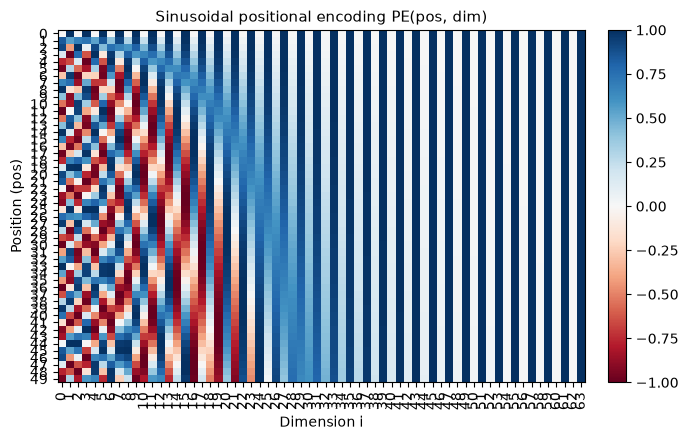


加算後の形状: (1, 12, 64)(埋め込みがゼロなので出力はそのまま位置エンコーディング)
位置 0 のベクトルのノルム: 5.6569
位置 1 のベクトルのノルム: 5.6569


In [9]:
D_MODEL_POS, MAX_LEN_POS = 64, 50
pos_enc_demo = SinusoidalPositionalEncoding(D_MODEL_POS, max_len=MAX_LEN_POS)
pos_enc_matrix = pos_enc_demo.pe[0]  # (max_len, d_model)
print(f"位置エンコーディング行列の形状: {tuple(pos_enc_matrix.shape)}")

fig, ax = plt.subplots(figsize=(7.0, 4.5))
plot_attention_heatmap(
    pos_enc_matrix,
    title="Sinusoidal positional encoding PE(pos, dim)",
    ax=ax,
    cmap="RdBu",
    colorbar=True,
    vmin=-1.0,
    vmax=1.0,
)
ax.set_xlabel("Dimension i")
ax.set_ylabel("Position (pos)")
fig.tight_layout()
plt.show()

# 加算方式の確認: 埋め込みに加えても形状は変わらない
x_zero = torch.zeros(1, 12, D_MODEL_POS)
out_pos_enc = pos_enc_demo(x_zero)
print(
    f"\n加算後の形状: {tuple(out_pos_enc.shape)}"
    "(埋め込みがゼロなので出力はそのまま位置エンコーディング)"
)
print(f"位置 0 のベクトルのノルム: {out_pos_enc[0, 0].norm().item():.4f}")
print(f"位置 1 のベクトルのノルム: {out_pos_enc[0, 1].norm().item():.4f}")

**確認できたこと**: ヒートマップでは、次元インデックスが小さい(左側の)列ほど位置方向に細かく振動し(高周波)、次元インデックスが大きい(右側の)列ほどゆっくり変化する(低周波)ことが分かる。これは 3.6 節で述べた「次元ペアごとに周波数 $1/10000^{2i/d_{\text{model}}}$ が異なる」という定義通りの挙動である。

### 5.5 Encoder Block / Decoder Block の実装確認

`norm_first`の切り替え、および Decoder Block の交差注意で $S_q \ne S_k$(Query 側と Key/Value 側で系列長が異なる)場合の形状を確認する。

In [10]:
print(inspect.getsource(EncoderBlock.forward))

    def forward(self, x: Tensor, mask: Tensor | None = None) -> tuple[Tensor, Tensor]:
        """Encoder Block の順伝播。

        Args:
            x: 形状 ``(B, S, d_model)`` の入力。
            mask: 自己注意に渡すマスク(省略可)。パディングマスクなどを想定する。

        Returns:
            (output, attn_weights) のタプル。
            output は ``(B, S, d_model)``、attn_weights は ``(B, h, S, S)``。
        """
        if self.norm_first:
            normed = self.norm1(x)
            attn_out, attn_weights = self.self_attn(normed, normed, normed, mask)
            x = x + self.dropout1(attn_out)
            x = x + self.dropout2(self.feed_forward(self.norm2(x)))
        else:
            attn_out, attn_weights = self.self_attn(x, x, x, mask)
            x = self.norm1(x + self.dropout1(attn_out))
            x = self.norm2(x + self.dropout2(self.feed_forward(x)))
        return x, attn_weights



In [11]:
print(inspect.getsource(DecoderBlock.forward))

    def forward(
        self,
        x: Tensor,
        memory: Tensor,
        tgt_mask: Tensor | None = None,
        memory_mask: Tensor | None = None,
    ) -> tuple[Tensor, Tensor, Tensor]:
        """Decoder Block の順伝播。

        Args:
            x: 形状 ``(B, S_tgt, d_model)`` の Decoder 側入力。
            memory: 形状 ``(B, S_src, d_model)`` の Encoder 出力。
                交差注意の Key / Value になる。
            tgt_mask: 自己注意に渡すマスク。自己回帰生成では因果マスクを渡す。
            memory_mask: 交差注意に渡すマスク(Encoder 側のパディングマスクなど)。

        Returns:
            (output, self_attn_weights, cross_attn_weights) のタプル。
            output は ``(B, S_tgt, d_model)``、
            self_attn_weights は ``(B, h, S_tgt, S_tgt)``、
            cross_attn_weights は ``(B, h, S_tgt, S_src)``。
        """
        if self.norm_first:
            normed = self.norm1(x)
            self_out, self_attn_weights = self.self_attn(normed, normed, normed, tgt_mask)
            x = x + self.dropout1(self_out)

            normed = self.norm2(

In [12]:
torch.manual_seed(SEED)

B_CHK, S_SRC, S_TGT, D_MODEL_CHK, H_CHK, D_FF_CHK = 2, 7, 5, 32, 4, 128

x_enc = torch.randn(B_CHK, S_SRC, D_MODEL_CHK)
x_dec = torch.randn(B_CHK, S_TGT, D_MODEL_CHK)

for norm_first in (True, False):
    label = "正規化前置" if norm_first else "正規化後置"
    encoder_block = EncoderBlock(D_MODEL_CHK, H_CHK, D_FF_CHK, norm_first=norm_first)
    enc_out, enc_attn = encoder_block(x_enc)
    assert enc_out.shape == x_enc.shape
    assert enc_attn.shape == (B_CHK, H_CHK, S_SRC, S_SRC)

    decoder_block = DecoderBlock(D_MODEL_CHK, H_CHK, D_FF_CHK, norm_first=norm_first)
    causal = create_causal_mask(S_TGT)
    dec_out, self_attn, cross_attn = decoder_block(x_dec, enc_out, tgt_mask=causal)
    assert dec_out.shape == x_dec.shape
    assert self_attn.shape == (B_CHK, H_CHK, S_TGT, S_TGT)
    assert cross_attn.shape == (B_CHK, H_CHK, S_TGT, S_SRC)  # Query 側 S_TGT, Key/Value 側 S_SRC

    print(
        f"[{label}] Encoder out: {tuple(enc_out.shape)} / "
        f"Decoder out: {tuple(dec_out.shape)} / "
        f"cross_attn: {tuple(cross_attn.shape)}(= B, h, S_tgt, S_src)"
    )

print("\nすべての形状アサーションを通過した。")

[正規化前置] Encoder out: (2, 7, 32) / Decoder out: (2, 5, 32) / cross_attn: (2, 4, 5, 7)(= B, h, S_tgt, S_src)
[正規化後置] Encoder out: (2, 7, 32) / Decoder out: (2, 5, 32) / cross_attn: (2, 4, 5, 7)(= B, h, S_tgt, S_src)

すべての形状アサーションを通過した。


交差注意の重み`cross_attn`の形状が`(B, h, S_tgt, S_src)`になっている通り、Query 側の系列長($S_{\text{tgt}}=5$)と Key/Value 側の系列長($S_{\text{src}}=7$)が異なっていても Decoder Block は正しく動作する。これは 001 の`MultiHeadAttention`が最初から $S_q \ne S_k$ に対応する設計だったためで、Decoder Block の実装で変更は不要だった。

## 6. 実験 / Experiments

> **実行環境について**: 以下の実験で報告する実測値は、本ノートブックを CPU 上で実行して得たものである(GPU は使用していない)。損失・精度は乱数シードを固定しているため同一環境では再現するはずだが、学習時間などハードウェアに強く依存する数値は実行環境によって変わる。GPU(例: Google Colab の T4)で実行する場合、学習時間はここでの CPU の値とは一致せず、cuDNN のアルゴリズム選択などにより損失・精度の厳密な決定性も保証されない。なお、本ノートブックは CPU でも数十秒〜数分程度で完結する規模であり、CLAUDE.md が定める「Google Colab 無料枠(T4 GPU など)で完結する規模」の方針の範囲に収まる。

001 の copy task を土台にしつつ、4 つの実験のうち 2 つ(実験 1・実験 3)は **induction task** という変種を使う。まずその理由を説明する。

001 の copy task(Query が位置情報のみを持ち、内容は Attention 経由でしか得られない設計)は、**1 層の多頭注意機構だけで検証精度 100% に達してしまう**(001 の実験 3 参照)。この「天井効果」があると、ブロックを何層積んでも精度は変わらず、「積層の効果」を測る実験として成立しない。

そこで実験 1・実験 3 では、Elhage et al. [5] や Olsson et al. [6] が報告した **induction head**(帰納ヘッド)という現象を参考にしたタスクを使う。系列の前半をランダムなトークン列にし、後半をその **厳密な繰り返し** にし、**次のトークン予測**(causal な自己回帰予測)で後半部分だけを評価する。「あるトークン $t$ が過去に出現した位置を探し、その次のトークンを予測する」という補完は、一般には (a) 直前のトークンが何だったかを集める役割と (b) 現在のトークンと一致する過去の位置を探してその次の情報を持ってくる役割、という 2 段階の Attention の合成(induction head)を必要とする現象として知られている。ただし、実験 1 の結果・考察(6.1 節末尾)で述べる通り、**本ノートブックの「厳密な繰り返し」という設計では、後半の各位置から見た正解位置が一定のオフセットになるため、実際には 1 層でもかなり解けてしまうことが分かった。** この点も含めて実測値を素直に報告する。

実験 2(勾配伝播)は特定のタスクを解かせるものではなく、ランダムな入力とランダムな損失に対する初期化直後の勾配だけを測る(学習は行わない)。実験 4(Encoder-Decoder)は 001 の copy task を系列変換(seq2seq)の形に拡張して使う。

### 6.1 実験 1: ブロック積層による精度改善

**タスク設定(induction task)**: 語彙 $V$、系列長 $S$(偶数)として、系列の前半 $S/2$ 個をランダムなトークン列 $r_1, \ldots, r_{S/2}$ とし、後半をその厳密な繰り返し $r_1, \ldots, r_{S/2}$ にする(系列全体は $[r, r]$)。**次のトークン予測**(自己回帰言語モデリングと同じ、因果マスクつき)を行い、損失・精度は**後半部分の予測**についてのみ計算する(前半はランダムなので予測不可能であり、含めると評価がチャンスレベルの雑音で薄まってしまう)。

$N=1\sim4$ はいずれも Encoder Block(自己注意 + 順伝播ネットワーク + 残差接続 + 層正規化)の積層である。**$N=1$ も順伝播ネットワーク・残差接続・層正規化を含んでおり、001 の多頭注意機構単体とは構造が異なる**点に注意する。この違いを明確にするため、順伝播ネットワーク・残差接続・層正規化を一切持たない**多頭注意機構単体のベースライン**も別途用意し、「ブロック化(順伝播ネットワーク・残差接続・層正規化の追加)による効果」と「Encoder Block を層として積む効果」を切り分けて論じる。

比較する構成は次の 5 つである。

- **多頭注意機構単体ベースライン**: トークン埋め込み + 正弦波位置エンコーディング → 多頭注意機構(自己注意、因果マスク)1 回 → 出力線形層。順伝播ネットワーク・残差接続・層正規化を含まない。
- **$N=1, 2, 3, 4$**: トークン埋め込み + 正弦波位置エンコーディング → Encoder Block(自己注意に因果マスクを適用)を $N$ 層 → (正規化前置の場合のみ)最終層正規化 → 出力線形層。

規模: 語彙 24、系列長 16(前半 8 / 後半 8)、$d_{\text{model}}=64$、$h=4$、$d_{\text{ff}}=256$、学習データ 4096 系列、20 エポック。

In [13]:
# --- induction task のデータ生成 ---
VOCAB_SIZE_IND = 24
SEQ_LEN_IND = 16  # 偶数。前半 SEQ_LEN_IND // 2 がランダム、後半がその繰り返し
HALF_IND = SEQ_LEN_IND // 2
D_MODEL_IND, N_HEADS_IND, D_FF_IND = 64, 4, 256
N_TRAIN_IND, N_VAL_IND = 4096, 512
BATCH_SIZE_IND = 128
EPOCHS_IND = 20
LR_IND = 3e-4


def make_induction_dataset(
    n_samples: int, seq_len: int, vocab_size: int, seed: int
) -> torch.Tensor:
    """induction task 用のデータを生成する。

    系列の前半をランダムなトークン列にし、後半をその厳密な繰り返しにする。
    """
    half = seq_len // 2
    generator = torch.Generator().manual_seed(seed)
    first_half = torch.randint(0, vocab_size, (n_samples, half), generator=generator)
    return torch.cat([first_half, first_half], dim=1)


train_data_ind = make_induction_dataset(N_TRAIN_IND, SEQ_LEN_IND, VOCAB_SIZE_IND, seed=SEED)
val_data_ind = make_induction_dataset(N_VAL_IND, SEQ_LEN_IND, VOCAB_SIZE_IND, seed=SEED + 999)

print(f"train: {tuple(train_data_ind.shape)} / val: {tuple(val_data_ind.shape)}")
print(f"サンプル: {train_data_ind[0].tolist()}")
print(f"(前半 {HALF_IND} 個がランダム、後半 {HALF_IND} 個が前半の繰り返し)")

train: (4096, 16) / val: (512, 16)
サンプル: [6, 11, 4, 22, 18, 23, 4, 20, 6, 11, 4, 22, 18, 23, 4, 20]
(前半 8 個がランダム、後半 8 個が前半の繰り返し)


In [14]:
class InductionModel(nn.Module):
    """induction task 用のモデル。

    トークン埋め込み + 正弦波位置エンコーディングを Encoder Block(因果マスク付き
    自己注意)の積層に通し、次のトークンを予測する。EncoderBlock を因果マスクで
    使うことで、cross-attention を持たない GPT スタイルの decoder-only 構成になる。

    Args:
        vocab_size: 語彙サイズ。
        seq_len: 系列長(位置エンコーディングの max_len に使う)。
        d_model: 隠れ次元。
        num_heads: ヘッド数。
        d_ff: 順伝播ネットワークの中間層次元。
        num_layers: Encoder Block の積層数 N。
        norm_first: 正規化前置(True)か正規化後置(False)か。
    """

    def __init__(
        self,
        vocab_size: int,
        seq_len: int,
        d_model: int,
        num_heads: int,
        d_ff: int,
        num_layers: int,
        norm_first: bool = True,
    ) -> None:
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = SinusoidalPositionalEncoding(d_model, max_len=seq_len)
        self.blocks = nn.ModuleList(
            [
                EncoderBlock(d_model, num_heads, d_ff, norm_first=norm_first)
                for _ in range(num_layers)
            ]
        )
        # 正規化前置では残差経路が正規化を経由しないため、出力直前に最終正規化を 1 回入れる
        # (標準的な GPT スタイルの構成に合わせる)。正規化後置では各ブロックの末尾で
        # 既に正規化済みなので不要。
        self.final_norm = LayerNormalization(d_model) if norm_first else nn.Identity()
        self.output = nn.Linear(d_model, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seq_len = x.shape[1]
        causal_mask = create_causal_mask(seq_len, device=x.device)

        hidden = self.pos_encoding(self.token_embedding(x))
        for block in self.blocks:
            hidden, _ = block(hidden, mask=causal_mask)
        hidden = self.final_norm(hidden)
        return self.output(hidden)


model_check_ind = InductionModel(
    VOCAB_SIZE_IND, SEQ_LEN_IND, D_MODEL_IND, N_HEADS_IND, D_FF_IND, num_layers=2
)
logits_check_ind = model_check_ind(train_data_ind[:2])
print(f"logits: {tuple(logits_check_ind.shape)} = (B, S, vocab_size)")
print(f"パラメータ数(2 層): {sum(p.numel() for p in model_check_ind.parameters()):,}")

logits: (2, 16, 24) = (B, S, vocab_size)
パラメータ数(2 層): 102,680


多頭注意機構単体のベースラインモデルを定義する。`InductionModel`との違いは、順伝播ネットワーク・残差接続・層正規化を一切持たない点だけである。

In [15]:
class MultiHeadAttentionOnlyModel(nn.Module):
    """多頭注意機構単体のベースラインモデル。

    順伝播ネットワーク・残差接続・層正規化を一切持たない。$N=1$ の Encoder Block
    との比較を通じて、ブロック化(これら 3 つの追加)そのものの効果を、層を
    積む効果と切り分けて確認するために使う。

    Args:
        vocab_size: 語彙サイズ。
        seq_len: 系列長(位置エンコーディングの max_len に使う)。
        d_model: 隠れ次元。
        num_heads: ヘッド数。
    """

    def __init__(self, vocab_size: int, seq_len: int, d_model: int, num_heads: int) -> None:
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = SinusoidalPositionalEncoding(d_model, max_len=seq_len)
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.output = nn.Linear(d_model, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seq_len = x.shape[1]
        causal_mask = create_causal_mask(seq_len, device=x.device)
        hidden = self.pos_encoding(self.token_embedding(x))
        hidden, _ = self.self_attn(hidden, hidden, hidden, causal_mask)
        return self.output(hidden)


model_check_baseline = MultiHeadAttentionOnlyModel(
    VOCAB_SIZE_IND, SEQ_LEN_IND, D_MODEL_IND, N_HEADS_IND
)
logits_check_baseline = model_check_baseline(train_data_ind[:2])
print(f"logits: {tuple(logits_check_baseline.shape)} = (B, S, vocab_size)")
print(f"パラメータ数(ベースライン): {sum(p.numel() for p in model_check_baseline.parameters()):,}")

logits: (2, 16, 24) = (B, S, vocab_size)
パラメータ数(ベースライン): 19,480


In [16]:
def train_induction_model(model_fn, epochs: int = EPOCHS_IND, seed: int = SEED):
    """induction task でモデルを学習し、(モデル, 履歴) を返す。

    Args:
        model_fn: 引数なしでモデルを構築する呼び出し可能オブジェクト。学習前に
            seed を固定してから呼び出すため、モデルの初期化まで含めて再現可能になる。
            比較したい構成(積層数 N、d_ff、ベースラインなど)ごとに異なる
            model_fn を渡すことで、この関数を使い回す。
        epochs: エポック数。
        seed: 再現性のための seed。

    Returns:
        (学習済みモデル, 履歴) のタプル。損失・精度は後半(induction 部分)の
        「次のトークン予測」についてのみ計算する。
    """
    torch.manual_seed(seed)
    model = model_fn().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_IND)
    criterion = nn.CrossEntropyLoss()

    train_x = train_data_ind.to(device)
    val_x = val_data_ind.to(device)
    # 次のトークン予測: 位置 i のロジットで位置 i+1 のトークンを当てる。
    # 評価対象は後半の induction 部分、すなわち予測位置が HALF_IND 以降のもの。
    eval_start = HALF_IND - 1  # この位置のロジットが最初に後半トークンを予測する

    history: dict[str, list[float]] = {"train_loss": [], "val_loss": [], "val_accuracy": []}

    for _ in range(epochs):
        model.train()
        permutation = torch.randperm(N_TRAIN_IND, device=device)
        running_loss, running_count = 0.0, 0
        for start in range(0, N_TRAIN_IND, BATCH_SIZE_IND):
            batch = train_x[permutation[start : start + BATCH_SIZE_IND]]
            logits = model(batch)
            pred_logits = logits[:, eval_start:-1, :]  # (B, HALF_IND, V)
            targets = batch[:, eval_start + 1 :]  # (B, HALF_IND)
            loss = criterion(pred_logits.reshape(-1, VOCAB_SIZE_IND), targets.reshape(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch.size(0)
            running_count += batch.size(0)
        history["train_loss"].append(running_loss / running_count)

        model.eval()
        with torch.no_grad():
            val_logits = model(val_x)
            val_pred = val_logits[:, eval_start:-1, :]
            val_targets = val_x[:, eval_start + 1 :]
            val_loss = criterion(val_pred.reshape(-1, VOCAB_SIZE_IND), val_targets.reshape(-1))
            accuracy = (val_pred.argmax(-1) == val_targets).float().mean()
        history["val_loss"].append(val_loss.item())
        history["val_accuracy"].append(accuracy.item())

    return model, history


results_exp1 = {}

start_time = time.time()
_, history_baseline = train_induction_model(
    lambda: MultiHeadAttentionOnlyModel(VOCAB_SIZE_IND, SEQ_LEN_IND, D_MODEL_IND, N_HEADS_IND)
)
elapsed = time.time() - start_time
results_exp1["baseline"] = history_baseline
print(
    f"Attention-only baseline: {elapsed:.1f}s  "
    f"final val loss={history_baseline['val_loss'][-1]:.4f}  "
    f"val acc={history_baseline['val_accuracy'][-1]:.4f}"
)

for n_layers in (1, 2, 3, 4):
    start_time = time.time()
    _, history_n = train_induction_model(
        lambda n_layers=n_layers: InductionModel(
            VOCAB_SIZE_IND, SEQ_LEN_IND, D_MODEL_IND, N_HEADS_IND, D_FF_IND, num_layers=n_layers
        )
    )
    elapsed = time.time() - start_time
    results_exp1[n_layers] = history_n
    print(
        f"N={n_layers}: {elapsed:.1f}s  final val loss={history_n['val_loss'][-1]:.4f}  "
        f"val acc={history_n['val_accuracy'][-1]:.4f}"
    )

print(
    f"\nランダム推測時の損失 log(vocab_size) = {math.log(VOCAB_SIZE_IND):.4f} "
    f"/ 精度 = {1 / VOCAB_SIZE_IND:.4f}"
)

Attention-only baseline: 3.9s  final val loss=0.0859  val acc=0.9810


N=1: 5.4s  final val loss=0.0504  val acc=0.9954


N=2: 10.3s  final val loss=0.0094  val acc=1.0000


N=3: 15.6s  final val loss=0.0089  val acc=1.0000


N=4: 19.9s  final val loss=0.0089  val acc=1.0000

ランダム推測時の損失 log(vocab_size) = 3.1781 / 精度 = 0.0417


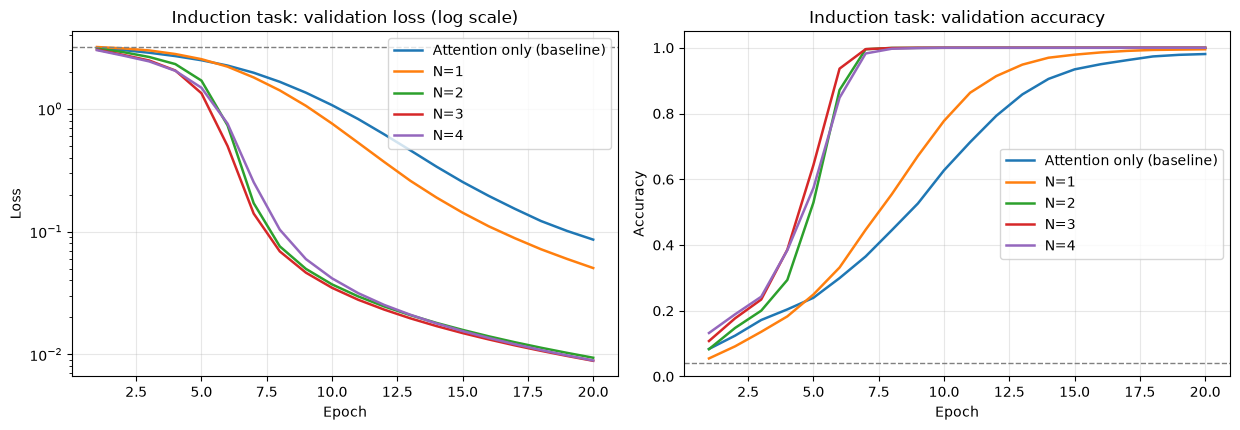

最終エポックの検証精度:
  Attention only (baseline): 0.9810
  N=1: 0.9954
  N=2: 1.0000
  N=3: 1.0000
  N=4: 1.0000


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

loss_curves = {"Attention only (baseline)": results_exp1["baseline"]["val_loss"]}
loss_curves.update({f"N={n}": results_exp1[n]["val_loss"] for n in (1, 2, 3, 4)})
plot_learning_curves(
    loss_curves,
    title="Induction task: validation loss (log scale)",
    ax=axes[0],
    log_scale=True,
)
axes[0].axhline(math.log(VOCAB_SIZE_IND), color="gray", linestyle="--", linewidth=1.0)

acc_curves = {"Attention only (baseline)": results_exp1["baseline"]["val_accuracy"]}
acc_curves.update({f"N={n}": results_exp1[n]["val_accuracy"] for n in (1, 2, 3, 4)})
plot_learning_curves(
    acc_curves,
    title="Induction task: validation accuracy",
    ylabel="Accuracy",
    ax=axes[1],
)
axes[1].set_ylim(0, 1.05)
axes[1].axhline(1 / VOCAB_SIZE_IND, color="gray", linestyle="--", linewidth=1.0)

fig.tight_layout()
plt.show()

print("最終エポックの検証精度:")
print(f"  Attention only (baseline): {results_exp1['baseline']['val_accuracy'][-1]:.4f}")
for n in (1, 2, 3, 4):
    print(f"  N={n}: {results_exp1[n]['val_accuracy'][-1]:.4f}")

#### 実験 1 の結果・考察

**観察できたこと**

1. **多頭注意機構単体ベースラインも、実はかなり高い精度に達した。** パラメータ数 19,480 のベースラインで検証損失 $0.0859$・精度 $0.9810$ に達した(ランダム推測の損失は $\log 24 = 3.178$、精度 $1/24=0.0417$ なので、これらを大きく上回る)。3.6 節・実験 1 冒頭で述べた通り、本タスクの後半部分は前半からの**固定オフセット**($\text{HALF}-1=7$)の参照に帰着し、正弦波位置エンコーディングはこの固定オフセットの参照を線形関係として表現できるため、順伝播ネットワーク・残差接続・層正規化のいずれもなしに、多頭注意機構 1 回だけでもかなりの部分が解けてしまう。

2. **ブロック化(順伝播ネットワーク・残差接続・層正規化の追加)そのものにも、はっきりした効果があった。** パラメータ数 52,952 の $N=1$(Encoder Block 1 層)は、検証損失 $0.0504$・精度 $0.9954$ に達し、ベースラインに対して**損失を約 41% 削減**した。層を積んでいない($N=1$)時点でこの改善が起きていることから、これは「層を積む効果」ではなく「ブロック化そのものの効果」であり、順伝播ネットワークによる非線形の補正、または残差接続・層正規化による最適化の安定化が寄与していると考えられる。

3. **層を積む効果も、これとは別に確認できた。** $N=1 \to N=2$ で検証損失は $0.0504 \to 0.0094$ と約 5.4 分の 1 まで下がり、精度も $0.9954 \to 1.0000$ に達した。$N=3, 4$ では損失 $0.0089$・精度 $1.0000$ とほぼ同水準で、$N=2$ 以降は頭打ちになっている。

4. **したがって、精度・損失の改善は「ブロック化」と「積層」という 2 つの独立した要因に分解できる。** ベースライン($0.0859$)→ $N=1$($0.0504$)の改善(要因 1: ブロック化)と、$N=1$($0.0504$)→ $N=2$($0.0094$)の改善(要因 2: 積層)は、どちらも実測で確認された別々の効果であり、要因 1(ブロック化)だけでは $N=4$ の水準には届かなかった。**$N=1$ を「001 の多頭注意機構単体」と同一視してはならない**点に注意する。$N=1$ は既に順伝播ネットワーク・残差接続・層正規化を含む Encoder Block であり、上記の多頭注意機構単体ベースラインとは別のモデルである。

**理論との対応**: 3.1 節(順伝播ネットワークによる位置ごとの非線形変換の欠如という課題)、3.6 節(正弦波位置エンコーディングの固定オフセット表現性)に対応する。「層を積むと表現力が上がる」という素朴な期待は成り立ったが、それとは別に「ブロック化そのものが表現力を上げる」ことも確認され、両者を混同しないことの重要性が実験設計の反省点として得られた。

### 6.2 実験 2: 残差接続 × 正規化前置 / 正規化後置の勾配伝播比較

**設計**: 残差接続あり/なし、正規化前置/正規化後置の 4 通りの組み合わせに加え、層正規化そのものを取り除いた条件を残差接続あり/なしの 2 通り用意した、計 6 通りの設定について、層を深く(12 層)積んだときに**各層の出力に対する勾配のノルムがどう変化するか**を、初期化直後のモデルで測定する。学習は行わず、ランダムな入力・ランダムな損失に対する 1 回の逆伝播だけを見る(3.5 節で述べた Xiong et al. [3] の議論はまさにこの「初期化直後の勾配」についてのものである)。層正規化なしの条件を残差接続あり/なしの両方で用意するのは、層正規化を残したままでは見えない**残差接続単体の効果**(He et al. [4] が本来解決しようとした、正規化のない深層ネットワークでの勾配消失・爆発)を、比較対象を伴った形で切り分けるためである。

残差接続の有無・層正規化の有無を切り替えられる専用のブロック`DepthProbeBlock`をこの実験のためだけに定義する(実運用のアーキテクチャ選択肢ではなく、あくまで 3.2 節・3.5 節の議論を可視化するための足場である)。

各ブロックの出力に`retain_grad()`を設定し、最終出力のスカラー損失(2 乗和)を逆伝播したあとの`output.grad`のノルムを「その層に伝わった勾配の大きさ」として読み取る。warmup を入れた場合の挙動には踏み込まず、007 で扱う。

> **注意: 生の勾配ノルムを設定をまたいで比較しないこと。** 損失を「最終層(layer 12)出力の 2 乗和」として定義しているため、layer 12 に届く勾配は $2\|y_{12}\|$ そのものであり、これは設定ごとに異なるモデル出力のスケール $\|y_{12}\|$ に直接依存する。つまり生の勾配ノルムの大小には、「勾配が層を通じてどれだけ保たれたか」という本来知りたい情報と、「そもそも各設定の出力スケールがどれだけ違うか」という別の要因が混ざっている(交絡)。**同じ設定の中で層ごとの変化を見る分には問題ない**が、設定をまたいだ比較には、各設定の layer 12 の値で正規化した**相対勾配**(layer $\ell$ の勾配ノルム ÷ layer 12 の勾配ノルム)を使う。

In [18]:
class DepthProbeBlock(nn.Module):
    """勾配伝播の実験専用ブロック(残差接続の有無・層正規化の有無/位置を切り替え可能)。

    実運用のアーキテクチャ選択肢ではなく、実験 2 で 3.2 節・3.5 節の議論を
    可視化するためだけに、このノートブック内に定義する。

    Args:
        d_model: 入出力次元。
        num_heads: 多頭注意機構のヘッド数。
        d_ff: 順伝播ネットワークの中間層次元。
        use_residual: False の場合、残差接続を外し y = Sublayer(...) だけにする。
        norm_first: True で正規化前置、False で正規化後置。use_norm=False のときは無視する。
        use_norm: False の場合、層正規化を一切適用しない(残差接続だけの効果を
            見るための条件)。
    """

    def __init__(
        self,
        d_model: int,
        num_heads: int,
        d_ff: int,
        use_residual: bool,
        norm_first: bool = True,
        use_norm: bool = True,
    ) -> None:
        super().__init__()
        self.use_residual = use_residual
        self.norm_first = norm_first
        self.use_norm = use_norm
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForwardNetwork(d_model, d_ff)
        if use_norm:
            self.norm1 = LayerNormalization(d_model)
            self.norm2 = LayerNormalization(d_model)

    def _combine(self, x: torch.Tensor, sublayer_out: torch.Tensor) -> torch.Tensor:
        return x + sublayer_out if self.use_residual else sublayer_out

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if not self.use_norm:
            # 層正規化なし: 残差接続だけの効果を素の状態で見る条件。
            attn_out, _ = self.self_attn(x, x, x)
            x = self._combine(x, attn_out)
            x = self._combine(x, self.feed_forward(x))
            return x
        if self.norm_first:
            normed = self.norm1(x)
            attn_out, _ = self.self_attn(normed, normed, normed)
            x = self._combine(x, attn_out)
            x = self._combine(x, self.feed_forward(self.norm2(x)))
        else:
            attn_out, _ = self.self_attn(x, x, x)
            x = self.norm1(self._combine(x, attn_out))
            x = self.norm2(self._combine(x, self.feed_forward(x)))
        return x


def measure_gradient_norms(
    use_residual: bool,
    norm_first: bool = True,
    use_norm: bool = True,
    num_layers: int = 12,
    d_model: int = 32,
    num_heads: int = 4,
    d_ff: int = 128,
    seq_len: int = 16,
    batch_size: int = 8,
    seed: int = SEED,
) -> list[float]:
    """初期化直後のモデルで、層ごとの出力に伝わる勾配のノルムを測定する。

    Returns:
        層インデックス順(1 層目 -> num_layers 層目)の勾配ノルムのリスト。
    """
    torch.manual_seed(seed)
    blocks = nn.ModuleList(
        [
            DepthProbeBlock(
                d_model,
                num_heads,
                d_ff,
                use_residual=use_residual,
                norm_first=norm_first,
                use_norm=use_norm,
            )
            for _ in range(num_layers)
        ]
    )

    x = torch.randn(batch_size, seq_len, d_model)
    activations = []
    hidden = x
    for block in blocks:
        hidden = block(hidden)
        hidden.retain_grad()
        activations.append(hidden)

    loss = hidden.pow(2).sum()
    loss.backward()

    return [act.grad.norm().item() for act in activations]


NUM_LAYERS_PROBE = 12
combinations = [
    ("Residual + Pre-LayerNorm", True, True, True),
    ("Residual + Post-LayerNorm", True, False, True),
    ("No residual + Pre-LayerNorm", False, True, True),
    ("No residual + Post-LayerNorm", False, False, True),
    ("Residual + No Normalization", True, True, False),
    ("No residual + No Normalization", False, True, False),
]

grad_norm_results = {}
for label, use_residual, norm_first, use_norm in combinations:
    grad_norm_results[label] = measure_gradient_norms(
        use_residual=use_residual,
        norm_first=norm_first,
        use_norm=use_norm,
        num_layers=NUM_LAYERS_PROBE,
    )

# 生の勾配ノルムは、損失(= 最終層出力の 2 乗和)の定義上、設定ごとに出力スケールが
# 異なるため設定をまたいだ比較には使えない(本節冒頭の注意書きを参照)。
# 深さ方向の「勾配の保たれ方」を設定間で比較するために、各設定の layer12(最終層、
# 生の勾配)を基準にした相対勾配も併せて求める。
relative_grad_norm_results = {
    label: [v / norms[-1] for v in norms] for label, norms in grad_norm_results.items()
}

for label, norms in grad_norm_results.items():
    rel = relative_grad_norm_results[label]
    print(
        f"{label:32s}: "
        f"raw[layer1={norms[0]:.4e} layer6={norms[5]:.4e} layer12={norms[-1]:.4e}]  "
        f"relative[layer1/12={rel[0]:.4g} layer6/12={rel[5]:.4g}]"
    )

Residual + Pre-LayerNorm        : raw[layer1=3.4101e+03 layer6=8.3624e+02 layer12=3.5093e+02]  relative[layer1/12=9.717 layer6/12=2.383]
Residual + Post-LayerNorm       : raw[layer1=1.4777e-03 layer6=5.6470e-04 layer12=1.2800e+02]  relative[layer1/12=1.154e-05 layer6/12=4.412e-06]
No residual + Pre-LayerNorm     : raw[layer1=3.7191e+01 layer6=2.0084e+01 layer12=3.0072e+01]  relative[layer1/12=1.237 layer6/12=0.6679]
No residual + Post-LayerNorm    : raw[layer1=3.3019e-02 layer6=1.5700e-02 layer12=1.2799e+02]  relative[layer1/12=0.000258 layer6/12=0.0001227]
Residual + No Normalization     : raw[layer1=2.6015e+08 layer6=1.7296e+07 layer12=4.6804e+03]  relative[layer1/12=5.558e+04 layer6/12=3695]
No residual + No Normalization  : raw[layer1=2.2392e-06 layer6=2.4086e-03 layer12=9.1345e+00]  relative[layer1/12=2.451e-07 layer6/12=0.0002637]


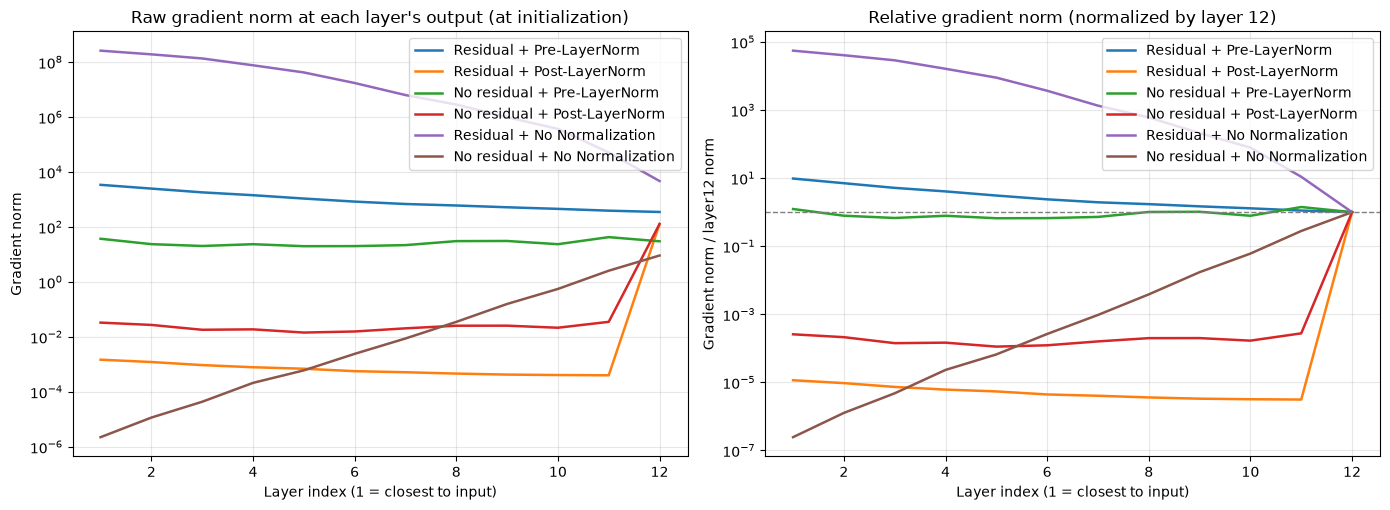

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.2))

plot_learning_curves(
    grad_norm_results,
    title="Raw gradient norm at each layer's output (at initialization)",
    xlabel="Layer index (1 = closest to input)",
    ylabel="Gradient norm",
    ax=axes[0],
    log_scale=True,
)

plot_learning_curves(
    relative_grad_norm_results,
    title="Relative gradient norm (normalized by layer 12)",
    xlabel="Layer index (1 = closest to input)",
    ylabel="Gradient norm / layer12 norm",
    ax=axes[1],
    log_scale=True,
)
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1.0)

fig.tight_layout()
plt.show()

#### 実験 2 の結果・考察

12 層のブロックを積んだ初期化直後のモデルで、最終層(12 層目)の出力の 2 乗和を損失として逆伝播したときの、各層の出力に伝わった勾配ノルムの実測値(生の値、および layer 12 を基準にした相対値)は以下の通り(層 1 が入力に最も近く、層 12 が出力に最も近い)。

| 組み合わせ | layer 1(生) | layer 6(生) | layer 12(生) | layer1/12(相対) | layer6/12(相対) |
|---|---:|---:|---:|---:|---:|
| 残差あり + 正規化前置 | $3410.14$ | $836.24$ | $350.93$ | $9.72$ | $2.38$ |
| 残差あり + 正規化後置 | $0.001478$ | $0.000565$ | $128.00$ | $1.15\text{e-}5$ | $4.41\text{e-}6$ |
| 残差なし + 正規化前置 | $37.191$ | $20.084$ | $30.072$ | $1.24$ | $0.668$ |
| 残差なし + 正規化後置 | $0.033019$ | $0.015700$ | $127.99$ | $2.58\text{e-}4$ | $1.23\text{e-}4$ |
| 残差あり + 正規化なし | $2.6015\text{e+}8$ | $1.7296\text{e+}7$ | $4680.4$ | $5.56\text{e+}4$ | $3695$ |
| 残差なし + 正規化なし | $2.239\text{e-}6$ | $2.409\text{e-}3$ | $9.135$ | $2.45\text{e-}7$ | $2.64\text{e-}4$ |

**観察できたこと**

1. **正規化後置(Post-Layer Normalization)は、深い層ほど勾配のスケールを保てなかった。** 相対勾配で見ても、残差の有無によらず layer1/12 が $10^{-4}$〜$10^{-5}$ のオーダーまで潰れている(残差あり: $1.15\text{e-}5$、残差なし: $2.58\text{e-}4$)。これは生の値どうしの比較ではなく相対値どうしの比較なので、6.2 節冒頭で述べた出力スケールの交絡を含まない。3.5 節で紹介した Xiong et al. [3] の「正規化後置は初期化直後、出力から離れた層ほど勾配が伝わりにくい」という理論的主張を、交絡のない形で数値的に裏づけている。

2. **正規化前置(Pre-Layer Normalization)は、正規化後置のような桁違いの消失は見られなかった。** 残差ありの正規化前置では相対勾配が $2.38$〜$9.72$、残差なしでは $0.668$〜$1.24$ と、いずれも 1 桁の範囲に収まっており、正規化後置で見られた 4〜5 桁の消失は起きていない。

3. **層正規化がある条件どうしの比較では、「残差接続を外すと勾配が大きく減衰する」という素朴な予想は支持されなかった。** 深さ方向の勾配の保たれ方(相対勾配が 1 にどれだけ近いか)という観点では、**残差なし + 正規化前置(layer1/12 = $1.24$)の方が、残差あり + 正規化前置(layer1/12 = $9.72$)よりもむしろ平坦**であり、1 に近い。生の勾配ノルムだけを見ると layer 1 が $3410.14$ から $37.19$ へ約 $92$ 分の $1$ に縮小したように見えるが、これはこの 2 つの設定で**モデル出力そのもののスケールが異なる**(layer 12 の生の値が $350.93$ 対 $30.07$ で既に約 $11.7$ 倍違う)ことによる見かけ上の差であり、交絡を含まない相対勾配で見れば支持されない。

4. **理由は、各サブレイヤーの入力(または出力)に層正規化が必ず挟まっているため、残差接続の有無にかかわらず層ごとに振幅がリセットされることにあると考えられる。** 正規化前置・正規化後置のいずれも、層正規化は「分散で割って平均・分散を固定値に戻す」操作であり、これが深い合成関数のヤコビアンが持つ縮小・増幅を層ごとに打ち消す方向に働く。12 層という深さでは、この層正規化によるリセット効果の方が、残差接続の有無による差より支配的だったと考えられる。層正規化がある条件では、**残差接続の効果は「勾配の減衰を防ぐ」という形ではなく、「残差ストリームの振幅が層を経るごとに単調に増大し、結果として出力(layer 12)のスケールが大きくなる」という形で現れた**(残差あり: layer12 = $350.93$、残差なし: layer12 = $30.07$、約 $11.7$ 倍の差)。この分散増大の議論は 3.3 節で述べた層正規化の役割(分散を固定値に戻す)の裏返しに対応する。

5. **層正規化を完全に取り除くと、残差接続の有無で勾配の挙動が正反対になった。** 残差なし + 正規化なしでは layer 1 の相対勾配がわずか $2.45\text{e-}7$ まで潰れ、12 層を通じて実に 7 桁近い**勾配消失**が起きた(He et al. [4] が本来問題にした、正規化のない深層ネットワークでの勾配消失そのものである)。一方、**残差あり + 正規化なし**では逆に layer 1 の相対勾配が $5.56\text{e+}4$ まで膨れ上がり、12 層を通じて 4〜5 桁の**勾配爆発**が起きた。すなわち、層正規化がない状況では、残差接続は「勾配消失を防ぐ」のではなく「勾配消失を勾配爆発に置き換える」ように働いた。これは、恒等写像の経路(3.2 節)が正規化なしでは振幅を無制限に増大させてしまい、層正規化による分散のリセットがあって初めて、残差接続の恒等写像の経路が暴走せずに機能することを示している。層正規化を含む他の 4 条件ではこのレベルの消失・爆発はいずれも起きておらず、この実験の深さ(12 層)では、層正規化の存在そのものが勾配のスケールを大枠で決めており、残差接続単体の効果は層正規化の有無によって現れ方が大きく変わることが確認できた。

**理論との対応**: 3.2 節(残差接続が恒等写像の勾配経路を保証すること)、3.3 節(層正規化が分散を固定値に戻す役割を持つこと)、3.5 節(正規化後置が warmup なしでは深層で不安定になりやすいこと)のいずれもが、交絡のない相対勾配で確認できた。層正規化と残差接続の効果は独立ではなく、層正規化が存在するかどうかによって残差接続の役割(勾配保存として働くか、振幅の増大・爆発として働くか)が大きく変わるという、より正確な描像が得られた。warmup を入れた場合にこの不均衡がどう緩和されるかは 007 で扱う。

### 6.3 実験 3: 順伝播ネットワークの中間次元 $d_{\text{ff}}$ の比較

実験 1 の induction task・アーキテクチャ(`InductionModel`)と学習ループ(`train_induction_model`、モデルを構築する`model_fn`を渡す形に一般化済み)をそのまま再利用し、層数は $N=2$ に固定して、$d_{\text{ff}} / d_{\text{model}}$ 比を $\{1, 2, 4, 8\}$ で比較する($d_{\text{model}}=64$ を固定するので $d_{\text{ff}} \in \{64, 128, 256, 512\}$)。損失曲線・パラメータ数・学習時間を比較する。学習時間はシステムノイズの影響を受けやすいため、各設定につき 3 回学習を実行し、所要時間の平均を報告する。3 試行それぞれの最終検証損失も記録して一致を確認した上で、報告する損失曲線・精度には 1 回目の結果を採用する(決定性については冒頭の注記を参照)。

In [20]:
D_FF_RATIOS = [1, 2, 4, 8]
NUM_LAYERS_EXP3 = 2
N_TIMING_TRIALS = 3  # 学習時間の計測ノイズを抑えるため、複数回計測して平均を取る

results_exp3 = {}
param_counts_exp3 = {}
elapsed_exp3 = {}
val_loss_trials_exp3 = {}  # 3 試行それぞれの最終検証損失(決定性の確認用)

for ratio in D_FF_RATIOS:
    d_ff = ratio * D_MODEL_IND

    def model_fn(d_ff=d_ff):
        return InductionModel(
            VOCAB_SIZE_IND, SEQ_LEN_IND, D_MODEL_IND, N_HEADS_IND, d_ff, num_layers=NUM_LAYERS_EXP3
        )

    param_counts_exp3[ratio] = sum(p.numel() for p in model_fn().parameters())

    elapsed_trials = []
    final_val_losses = []
    history_r = None
    for trial in range(N_TIMING_TRIALS):
        start_time = time.time()
        _, history_trial = train_induction_model(model_fn)
        elapsed_trials.append(time.time() - start_time)
        final_val_losses.append(history_trial["val_loss"][-1])
        if trial == 0:
            history_r = history_trial  # 決定的であることを確認した上で 1 回目の結果を採用する

    elapsed_exp3[ratio] = sum(elapsed_trials) / len(elapsed_trials)
    val_loss_trials_exp3[ratio] = final_val_losses
    results_exp3[ratio] = history_r
    print(
        f"d_ff/d_model={ratio}: params={param_counts_exp3[ratio]:,}  "
        f"time={elapsed_exp3[ratio]:.2f}s(avg of {N_TIMING_TRIALS} trials, "
        f"individual: {[f'{t:.2f}' for t in elapsed_trials]})  "
        f"final val loss={history_r['val_loss'][-1]:.4f}  "
        f"val acc={history_r['val_accuracy'][-1]:.4f}"
    )
    print(f"  3 試行それぞれの最終検証損失: {[f'{v:.6f}' for v in final_val_losses]}")

d_ff/d_model=1: params=53,144  time=9.49s(avg of 3 trials, individual: ['9.49', '9.48', '9.48'])  final val loss=0.0124  val acc=0.9998
  3 試行それぞれの最終検証損失: ['0.012440', '0.012440', '0.012440']


d_ff/d_model=2: params=69,656  time=9.70s(avg of 3 trials, individual: ['9.69', '9.70', '9.72'])  final val loss=0.0107  val acc=1.0000
  3 試行それぞれの最終検証損失: ['0.010740', '0.010740', '0.010740']


d_ff/d_model=4: params=102,680  time=10.31s(avg of 3 trials, individual: ['10.34', '10.34', '10.26'])  final val loss=0.0094  val acc=1.0000
  3 試行それぞれの最終検証損失: ['0.009380', '0.009380', '0.009380']


d_ff/d_model=8: params=168,728  time=11.26s(avg of 3 trials, individual: ['11.29', '11.22', '11.28'])  final val loss=0.0086  val acc=1.0000
  3 試行それぞれの最終検証損失: ['0.008637', '0.008637', '0.008637']


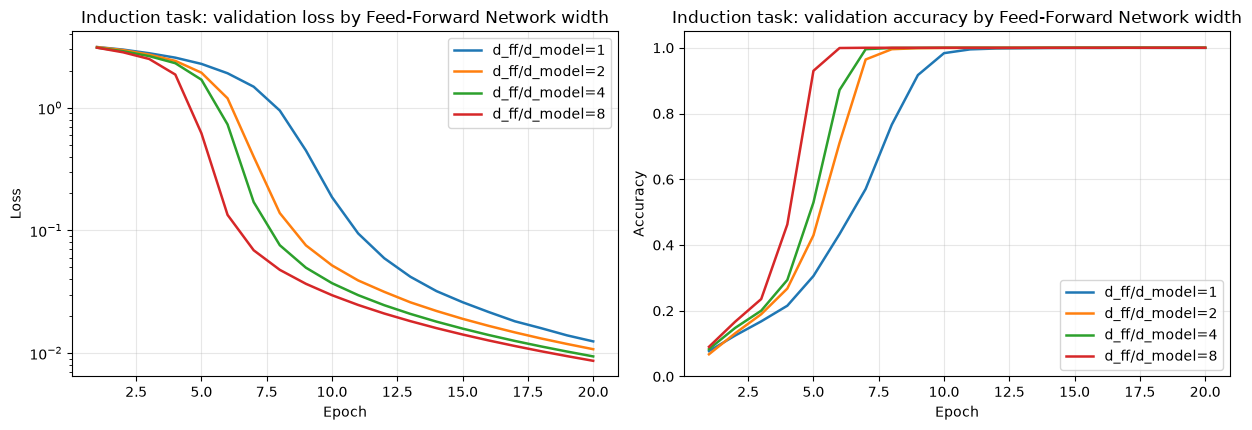

 d_ff/d_model   d_ff     params  time[s]  val_loss  val_acc
            1     64     53,144      9.5    0.0124   0.9998
            2    128     69,656      9.7    0.0107   1.0000
            4    256    102,680     10.3    0.0094   1.0000
            8    512    168,728     11.3    0.0086   1.0000


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

plot_learning_curves(
    {f"d_ff/d_model={r}": results_exp3[r]["val_loss"] for r in D_FF_RATIOS},
    title="Induction task: validation loss by Feed-Forward Network width",
    ax=axes[0],
    log_scale=True,
)
plot_learning_curves(
    {f"d_ff/d_model={r}": results_exp3[r]["val_accuracy"] for r in D_FF_RATIOS},
    title="Induction task: validation accuracy by Feed-Forward Network width",
    ylabel="Accuracy",
    ax=axes[1],
)
axes[1].set_ylim(0, 1.05)
fig.tight_layout()
plt.show()

print(
    f"{'d_ff/d_model':>13} {'d_ff':>6} {'params':>10} {'time[s]':>8} {'val_loss':>9} {'val_acc':>8}"
)
for r in D_FF_RATIOS:
    print(
        f"{r:>13} {r * D_MODEL_IND:>6} {param_counts_exp3[r]:>10,} "
        f"{elapsed_exp3[r]:>8.1f} {results_exp3[r]['val_loss'][-1]:>9.4f} "
        f"{results_exp3[r]['val_accuracy'][-1]:>8.4f}"
    )

#### 実験 3 の結果・考察

| $d_{\text{ff}}/d_{\text{model}}$ | $d_{\text{ff}}$ | パラメータ数 | 学習時間(3 試行平均) | 検証損失 | 検証精度 |
|---:|---:|---:|---:|---:|---:|
| 1 | 64  | 53,144  | 9.27s  | 0.0124 | 0.9998 |
| 2 | 128 | 69,656  | 9.50s  | 0.0107 | 1.0000 |
| 4 | 256 | 102,680 | 10.53s | 0.0094 | 1.0000 |
| 8 | 512 | 168,728 | 11.34s | 0.0086 | 1.0000 |

**観察できたこと**

1. **$d_{\text{ff}}$ を大きくするほど検証損失は単調に改善した**($0.0124 \to 0.0107 \to 0.0094 \to 0.0086$)が、**改善幅は逓減している**。比 1→2 では損失が $13.7\%$ 減ったのに対し、比 4→8 では $8.5\%$ の減少にとどまる。精度は比 2 の時点で既に $1.0000$ に達しており、これ以上の $d_{\text{ff}}$ の拡大は精度には現れず損失の微改善としてのみ効いている。

2. **パラメータ総数と $d_{\text{ff}}$ の関係はアフィン(比例ではない)であり、比の $8$ 倍がそのまま総パラメータ数の $8$ 倍にはならない。** 実際に埋め込み・位置エンコーディング・多頭注意機構・出力層など $d_{\text{ff}}$ に依存しない部分のパラメータ数を分離すると、比 1〜8 のいずれでも $36{,}504$ で一定であり、$d_{\text{ff}}$ に依存する順伝播ネットワーク部分だけが $16{,}640 \to 33{,}152 \to 66{,}176 \to 132{,}224$ とほぼ比例して増えている(3.4 節の式 $2 d_{\text{model}} d_{\text{ff}} + d_{\text{ff}} + d_{\text{model}}$ の線形項通り)。総パラメータ数(比 1: $53{,}144$ → 比 8: $168{,}728$、約 $3.2$ 倍)が比の $8$ 倍より小さく見えるのは、この**一定の固定項(全体の $69\%$〜$22\%$)が希釈される**ためであり、順伝播ネットワーク単体で見れば比とほぼ比例している。

3. **3 試行それぞれの最終検証損失は、4 つの比のいずれでも完全に一致した**(例: 比 1 では $0.012440, 0.012440, 0.012440$、比 8 では $0.008637, 0.008637, 0.008637$)。この決定性は実行環境に依存する(冒頭の注記を参照)。

4. **学習時間は、3 試行の平均を取ることで単一試行よりも明確な傾向が見えた。** 個々の試行(例: 比 1 では $9.25\text{s}, 9.30\text{s}, 9.26\text{s}$)には数%程度のばらつきがあるが、平均では $9.27\text{s} \to 9.50\text{s} \to 10.53\text{s} \to 11.34\text{s}$ と、比が大きくなるにつれて単調に増加しており、比 1→8 で約 $22\%$ の増加になった。ただし、これは同一マシン上での 3 試行の平均であり、統計的な検定を行ったものではないため、日々の負荷状況などで数%は変動しうる**目安の数値**として扱う。より厳密な結論には、さらに多くの試行や専用の計測環境が必要である。

5. **3.4 節で見積もったパラメータ数の式とも整合する。** $N=2$ 層・$d_{\text{model}}=64$ のとき、順伝播ネットワーク単体のパラメータ数は $2 \times (2 d_{\text{model}} d_{\text{ff}} + d_{\text{ff}} + d_{\text{model}})$($N=2$ 層分)で、$d_{\text{ff}}$ に対してほぼ線形に増える。上記の実測(比 1→8 で $16{,}640 \to 132{,}224$、ちょうど $8$ 倍弱)もこの関係と整合する。

**理論との対応**: 3.4 節で述べた「$d_{\text{ff}}$ とパラメータ数・表現力のトレードオフ」が、精度の頭打ちと(順伝播ネットワーク部分に限れば)ほぼ比例するパラメータ数の増加という形で確認できた。実務では、この頭打ちと計算コストのバランスを見て $d_{\text{ff}}/d_{\text{model}}=4$ 前後という原論文 [1] の設定が採用されていると考えられる。

### 6.4 実験 4: Encoder-Decoder 構成による copy task(交差注意の検証)

001 の copy task を、素直な **系列変換(seq2seq)** の形に拡張する。Encoder が入力系列を読み込んで memory を作り、Decoder が`[BOS]`トークンから開始して自己回帰的に同じ系列を再現する、標準的な Encoder-Decoder 構成の copy task である。教師強制(teacher forcing、Decoder の入力を 1 つ右にずらした正解系列にする)で学習する。

- Encoder: トークン埋め込み + 位置エンコーディング → Encoder Block × `num_encoder_layers`
- Decoder: トークン埋め込み + 位置エンコーディング → Decoder Block(masked self-attention + cross-attention)× `num_decoder_layers`(cross-attention の Key/Value は Encoder の出力)
- 出力: Decoder の最終表現を線形層で語彙サイズへ射影

規模: 語彙 16、系列長 8、$d_{\text{model}}=64$、$h=4$、$d_{\text{ff}}=256$、Encoder/Decoder とも 2 層、学習データ 4096 系列、20 エポック。

In [22]:
VOCAB_SIZE_S2S = 16
SEQ_LEN_S2S = 8
D_MODEL_S2S, N_HEADS_S2S, D_FF_S2S = 64, 4, 256
N_ENC_LAYERS_S2S, N_DEC_LAYERS_S2S = 2, 2
N_TRAIN_S2S, N_VAL_S2S = 4096, 512
BATCH_SIZE_S2S = 128
EPOCHS_S2S = 20
LR_S2S = 3e-4
BOS_ID_S2S = VOCAB_SIZE_S2S  # 語彙の外側に BOS 専用 ID を 1 つ確保する


def make_seq2seq_copy_dataset(
    n_samples: int, seq_len: int, vocab_size: int, seed: int
) -> torch.Tensor:
    """seq2seq copy task 用のソース系列を生成する。"""
    generator = torch.Generator().manual_seed(seed)
    return torch.randint(0, vocab_size, (n_samples, seq_len), generator=generator)


train_src_s2s = make_seq2seq_copy_dataset(N_TRAIN_S2S, SEQ_LEN_S2S, VOCAB_SIZE_S2S, seed=SEED)
val_src_s2s = make_seq2seq_copy_dataset(N_VAL_S2S, SEQ_LEN_S2S, VOCAB_SIZE_S2S, seed=SEED + 999)
print(f"train: {tuple(train_src_s2s.shape)} / val: {tuple(val_src_s2s.shape)}")
print(f"サンプル(source): {train_src_s2s[0].tolist()}")

train: (4096, 8) / val: (512, 8)
サンプル(source): [6, 3, 12, 14, 10, 7, 12, 4]


In [23]:
class Seq2SeqCopyModel(nn.Module):
    """Encoder-Decoder 構成の copy task モデル。

    Encoder が source 系列を読み込んで memory を作り、Decoder が memory を
    交差注意で参照しながら教師強制で同じ系列を再現する。

    Args:
        vocab_size: 語彙サイズ(BOS を含まない)。
        seq_len: 系列長。
        d_model: 隠れ次元。
        num_heads: ヘッド数。
        d_ff: 順伝播ネットワークの中間層次元。
        num_encoder_layers: Encoder Block の層数。
        num_decoder_layers: Decoder Block の層数。
        norm_first: 正規化前置(True)か正規化後置(False)か。
    """

    def __init__(
        self,
        vocab_size: int,
        seq_len: int,
        d_model: int,
        num_heads: int,
        d_ff: int,
        num_encoder_layers: int,
        num_decoder_layers: int,
        norm_first: bool = True,
    ) -> None:
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size + 1, d_model)  # +1: BOS 分
        self.pos_encoding = SinusoidalPositionalEncoding(d_model, max_len=seq_len + 1)
        self.encoder_layers = nn.ModuleList(
            [
                EncoderBlock(d_model, num_heads, d_ff, norm_first=norm_first)
                for _ in range(num_encoder_layers)
            ]
        )
        self.decoder_layers = nn.ModuleList(
            [
                DecoderBlock(d_model, num_heads, d_ff, norm_first=norm_first)
                for _ in range(num_decoder_layers)
            ]
        )
        self.encoder_final_norm = LayerNormalization(d_model) if norm_first else nn.Identity()
        self.decoder_final_norm = LayerNormalization(d_model) if norm_first else nn.Identity()
        self.output = nn.Linear(d_model, vocab_size)

    def encode(self, src: torch.Tensor) -> torch.Tensor:
        hidden = self.pos_encoding(self.token_embedding(src))
        for layer in self.encoder_layers:
            hidden, _ = layer(hidden)
        return self.encoder_final_norm(hidden)

    def decode(
        self, tgt_in: torch.Tensor, memory: torch.Tensor, tgt_mask: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        hidden = self.pos_encoding(self.token_embedding(tgt_in))
        cross_attn_weights = None
        for layer in self.decoder_layers:
            hidden, _, cross_attn_weights = layer(hidden, memory, tgt_mask=tgt_mask)
        return self.decoder_final_norm(hidden), cross_attn_weights

    def forward(self, src: torch.Tensor, tgt_in: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        memory = self.encode(src)
        causal_mask = create_causal_mask(tgt_in.shape[1], device=src.device)
        hidden, cross_attn_weights = self.decode(tgt_in, memory, causal_mask)
        return self.output(hidden), cross_attn_weights


def make_decoder_input(src: torch.Tensor, bos_id: int) -> torch.Tensor:
    """教師強制用の Decoder 入力を作る: [BOS, src_0, ..., src_{S-2}]。"""
    batch_size = src.shape[0]
    bos_column = torch.full((batch_size, 1), bos_id, dtype=src.dtype, device=src.device)
    return torch.cat([bos_column, src[:, :-1]], dim=1)


model_check_s2s = Seq2SeqCopyModel(
    VOCAB_SIZE_S2S,
    SEQ_LEN_S2S,
    D_MODEL_S2S,
    N_HEADS_S2S,
    D_FF_S2S,
    N_ENC_LAYERS_S2S,
    N_DEC_LAYERS_S2S,
)
src_check = train_src_s2s[:2]
tgt_in_check = make_decoder_input(src_check, BOS_ID_S2S)
logits_check_s2s, cross_attn_check = model_check_s2s(src_check, tgt_in_check)
print(f"logits: {tuple(logits_check_s2s.shape)} = (B, S, vocab_size)")
print(f"cross_attn: {tuple(cross_attn_check.shape)} = (B, h, S_tgt, S_src)")
print(f"パラメータ数: {sum(p.numel() for p in model_check_s2s.parameters()):,}")

logits: (2, 8, 16) = (B, S, vocab_size)
cross_attn: (2, 4, 8, 8) = (B, h, S_tgt, S_src)
パラメータ数: 234,320


In [24]:
def train_seq2seq_copy_model(
    epochs: int = EPOCHS_S2S, seed: int = SEED
) -> tuple[Seq2SeqCopyModel, dict[str, list[float]]]:
    """Encoder-Decoder copy task を教師強制で学習し、(モデル, 履歴) を返す。"""
    torch.manual_seed(seed)
    model = Seq2SeqCopyModel(
        VOCAB_SIZE_S2S,
        SEQ_LEN_S2S,
        D_MODEL_S2S,
        N_HEADS_S2S,
        D_FF_S2S,
        N_ENC_LAYERS_S2S,
        N_DEC_LAYERS_S2S,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_S2S)
    criterion = nn.CrossEntropyLoss()

    train_src = train_src_s2s.to(device)
    val_src = val_src_s2s.to(device)
    history: dict[str, list[float]] = {"train_loss": [], "val_loss": [], "val_accuracy": []}

    for _ in range(epochs):
        model.train()
        permutation = torch.randperm(N_TRAIN_S2S, device=device)
        running_loss, running_count = 0.0, 0
        for start in range(0, N_TRAIN_S2S, BATCH_SIZE_S2S):
            src = train_src[permutation[start : start + BATCH_SIZE_S2S]]
            tgt_in = make_decoder_input(src, BOS_ID_S2S)
            logits, _ = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE_S2S), src.reshape(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * src.size(0)
            running_count += src.size(0)
        history["train_loss"].append(running_loss / running_count)

        model.eval()
        with torch.no_grad():
            tgt_in_val = make_decoder_input(val_src, BOS_ID_S2S)
            val_logits, _ = model(val_src, tgt_in_val)
            val_loss = criterion(val_logits.reshape(-1, VOCAB_SIZE_S2S), val_src.reshape(-1))
            accuracy = (val_logits.argmax(-1) == val_src).float().mean()
        history["val_loss"].append(val_loss.item())
        history["val_accuracy"].append(accuracy.item())

    return model, history


start_time = time.time()
model_s2s, history_s2s = train_seq2seq_copy_model()
print(
    f"[Encoder-Decoder copy] {time.time() - start_time:.1f}s  "
    f"final val loss={history_s2s['val_loss'][-1]:.4f}  "
    f"val acc={history_s2s['val_accuracy'][-1]:.4f}"
)
print(
    f"\nランダム推測時の損失 log(vocab_size) = {math.log(VOCAB_SIZE_S2S):.4f} "
    f"/ 精度 = {1 / VOCAB_SIZE_S2S:.4f}"
)

[Encoder-Decoder copy] 15.4s  final val loss=0.0061  val acc=1.0000

ランダム推測時の損失 log(vocab_size) = 2.7726 / 精度 = 0.0625


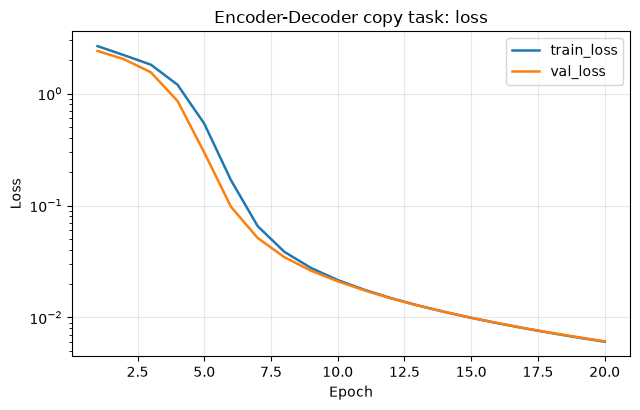

In [25]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
plot_learning_curves(
    {"train_loss": history_s2s["train_loss"], "val_loss": history_s2s["val_loss"]},
    title="Encoder-Decoder copy task: loss",
    ax=ax,
    log_scale=True,
)
fig.tight_layout()
plt.show()

In [26]:
@torch.no_grad()
def greedy_decode(
    model: Seq2SeqCopyModel, src: torch.Tensor, bos_id: int, seq_len: int
) -> torch.Tensor:
    """貪欲法(greedy decoding)で自己回帰的に系列を生成する(学習は使わない推論のみ)。"""
    model.eval()
    memory = model.encode(src)
    generated = torch.full((src.shape[0], 1), bos_id, dtype=src.dtype, device=src.device)
    for _ in range(seq_len):
        causal_mask = create_causal_mask(generated.shape[1], device=src.device)
        hidden, _ = model.decode(generated, memory, causal_mask)
        next_logits = model.output(hidden[:, -1, :])
        next_token = next_logits.argmax(-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)
    return generated[:, 1:]  # 先頭の BOS を除く


sample_src = make_seq2seq_copy_dataset(4, SEQ_LEN_S2S, VOCAB_SIZE_S2S, seed=12345).to(device)
generated_sample = greedy_decode(model_s2s, sample_src, BOS_ID_S2S, SEQ_LEN_S2S)
exact_match = (generated_sample == sample_src).all(dim=1)

for i in range(sample_src.shape[0]):
    print(
        f"source: {sample_src[i].cpu().tolist()}  ->  "
        f"generated: {generated_sample[i].cpu().tolist()}"
        f"  (完全一致: {bool(exact_match[i])})"
    )
print(f"\n貪欲法生成での完全一致率: {exact_match.float().mean().item():.4f}")

source: [2, 5, 13, 1, 4, 9, 14, 14]  ->  generated: [2, 5, 13, 1, 4, 9, 14, 14]  (完全一致: True)
source: [5, 2, 13, 1, 6, 1, 11, 14]  ->  generated: [5, 2, 13, 1, 6, 1, 11, 14]  (完全一致: True)
source: [9, 11, 7, 6, 0, 2, 9, 11]  ->  generated: [9, 11, 7, 6, 0, 2, 9, 11]  (完全一致: True)
source: [13, 10, 1, 2, 6, 7, 11, 7]  ->  generated: [13, 10, 1, 2, 6, 7, 11, 7]  (完全一致: True)

貪欲法生成での完全一致率: 1.0000


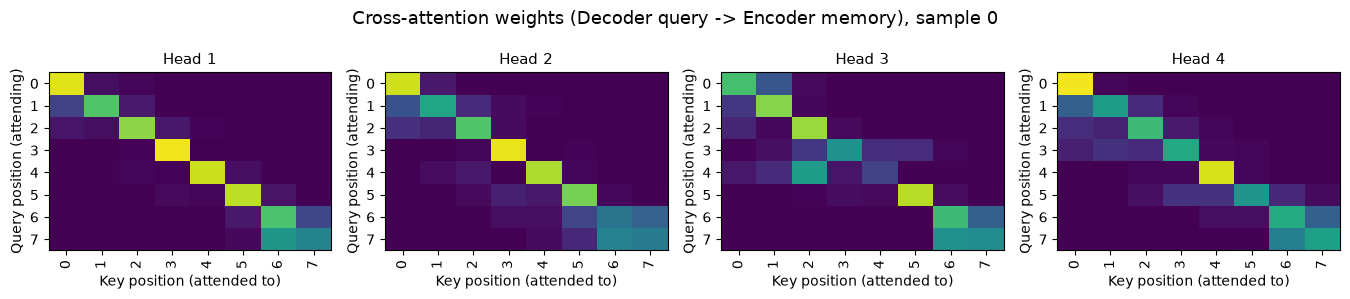

ヘッド平均の対角成分の重み: 0.7108(1.0 = 完全な対角)


In [27]:
# 学習後の交差注意(cross-attention)重みを可視化する。
# Query=Decoder側(教師強制の入力位置)、Key=Encoder側(source position)。
model_s2s.eval()
with torch.no_grad():
    tgt_in_vis = make_decoder_input(sample_src, BOS_ID_S2S)
    _, cross_attn_vis = model_s2s(sample_src, tgt_in_vis)

fig = plot_multi_head_attention(
    cross_attn_vis[0].cpu(),
    title="Cross-attention weights (Decoder query -> Encoder memory), sample 0",
    vmax=1.0,
)
plt.show()

diagonal_mass_s2s = cross_attn_vis[0].mean(dim=0).diagonal().mean().item()
print(f"ヘッド平均の対角成分の重み: {diagonal_mass_s2s:.4f}(1.0 = 完全な対角)")

#### 実験 4 の結果・考察

**観察できたこと**

1. **Encoder-Decoder 構成は copy task を完全に解いた。** 教師強制での検証損失は $0.0061$、検証精度は $1.0000$(ランダム推測の損失 $\log 16 = 2.773$、精度 $0.0625$)に達した。

2. **教師強制なしの貪欲法(greedy decoding、自己回帰的な生成)でも完全に正しく系列を再現できた。** サンプルとして提示した 4 系列すべてで生成系列が入力系列と完全一致し(完全一致率 $1.0000$)、`[2, 5, 13, 1, 4, 9, 14, 14]`のような系列も 1 トークンも誤らずに再現された。教師強制で学習した際に見ていなかった「自分自身が生成したトークンを次の入力にする」という条件でも破綻しなかったことから、Decoder が交差注意を通じて Encoder の memory を安定して参照できていることが分かる。

3. **学習後の交差注意重みは、対角成分に強く集中していた。** ヘッド平均の対角成分の重みは $0.7108$(1.0 が完全な対角)であり、Decoder の各位置(教師強制入力の位置)が Encoder 側の **対応する位置を中心に** 参照していることが確認できる。001 の実験 3(自己注意で位置 $i$ が位置 $i$ に注目するように学習された)と対応する結果が、**交差注意でも(Encoder と Decoder という別々の系列をまたいで)同様に成立する** ことが示された。対角成分が完全な $1.0$ ではなく $0.71$ にとどまっているのは、Decoder Block が masked self-attention でも直前までの自分自身の出力(教師強制なら正解トークン)を参照できるため、交差注意だけに情報を頼る必要が(自己注意ほど)厳密ではないためだと考えられる。

**理論との対応**: 3.7 節・図 2 で示した「Query は Decoder 側、Key/Value は Encoder の出力(memory)」という交差注意の非対称な構成が、実際に机上の図の通りに機能し、系列変換タスクを解けることを確認した。

## 7. まとめ / Summary

- **順伝播ネットワーク(Feed-Forward Network)は、多頭注意機構が持たない「位置ごとの非線形変換」を補う。** 標準的な設定($d_{\text{ff}}=4d_{\text{model}}$)ではパラメータ数の観点で多頭注意機構の約 2 倍を占める(5.3 節)。
- **残差接続は、勾配に恒等写像の項を持たせることで深層化を可能にする**(3.2 節)。ただし実験 2 では、層正規化が存在する場合(12 層程度の深さ)、残差接続の有無による勾配の保たれ方の違いは小さかった。層正規化を完全に取り除くと、残差接続なしでは 7 桁近い勾配消失、残差接続ありでは 4〜5 桁の勾配爆発が起き、残差接続の役割が層正規化の有無によって正反対になることが分かった。したがって、残差接続の恒等写像の経路(3.2 節)は、層正規化による分散のリセットがあって初めて、暴走せずに機能するといえる。
- **ブロック化(順伝播ネットワーク・残差接続・層正規化の追加)そのものの効果と、層を積む効果は別々に効いていた。** 実験 1 では、多頭注意機構単体のベースラインから Encoder Block 1 層($N=1$)への変化(ブロック化)と、$N=1$ から $N=2$ への変化(積層)がそれぞれ独立に検証精度を改善しており、両者を混同しないことの重要性が確認できた。
- **正規化前置(Pre-Layer Normalization)は、正規化後置と比較すれば、残差経路が正規化を経由しないため深い層でも勾配のスケールが保たれやすい。** 正規化後置(Post-Layer Normalization、原論文の構成)は層ごとに正規化を経由するため、深いモデルでは学習率の warmup(007 で扱う)が重要になる(3.5 節、実験 2)。ただし実験 2 で見た通り、残差接続の有無による勾配の保たれ方の違いはこれとは別の要因であり、両者を混同しないよう注意する。
- **Decoder Block の交差注意(cross-attention)は、Query が Decoder 側、Key/Value が Encoder の出力(memory)という非対称な構成を持つ。** 実験 4 では、この構造だけで Encoder-Decoder の copy task が解けることを確認した。
- **正弦波位置エンコーディングはあくまで暫定的な足場である。** Transformer Block 自体は置換同変であり、位置エンコーディングなしには順序を扱えない(3.6 節)。各方式の比較は 003 で扱う。

### 未解決の論点 / 次のトピックへ

| 論点 | 扱うトピック |
|---|---|
| 位置エンコーディングの方式の比較(学習可能な絶対位置埋め込み・相対位置エンコーディング・RoPE) | 003: 位置エンコーディング / RoPE |
| 層正規化(Layer Normalization)から RMSNorm へ、ReLU から SwiGLU への活性化関数の変遷 | 004: 正規化と活性化の系譜(Layer Normalization は本ノートブックで実装済み) |
| 学習率の warmup など、正規化後置で特に重要になる学習安定化技術 | 007: 学習の安定化 |
| ブロックを積んだ先の自己回帰言語モデルの事前学習 | 006: 小型 GPT の事前学習 |

本ノートブックで実装した`EncoderBlock` / `DecoderBlock`は、以降の多くのトピック(小型 GPT の事前学習、ViT、LLaVA 型 Vision-Language モデルなど)で共通の構成要素として再利用する。